In [2]:
"""Composition parsing and validation helpers copied from main.py."""

import csv
import re
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable


ELEMENT_SYMBOLS = frozenset(
    "H He Li Be B C N O F Ne Na Mg Al Si P S Cl Ar K Ca Sc Ti V Cr Mn Fe Co Ni "
    "Cu Zn Ga Ge As Se Br Kr Rb Sr Y Zr Nb Mo Tc Ru Rh Pd Ag Cd In Sn Sb Te I Xe "
    "Cs Ba La Ce Pr Nd Pm Sm Eu Gd Tb Dy Ho Er Tm Yb Lu Hf Ta W Re Os Ir Pt Au Hg "
    "Tl Pb Bi Po At Rn Fr Ra Ac Th Pa U Np Pu Am Cm Bk Cf Es Fm Md No Lr Rf Db Sg Bh "
    "Hs Mt Ds Rg Cn Nh Fl Mc Lv Ts Og REE".split()
)
SYMBOLS_BY_LENGTH = tuple(sorted(ELEMENT_SYMBOLS, key=len, reverse=True))
CHARGE_PATTERN = re.compile(
    r"^(?:(?P<sign_first>[+-])(?P<magnitude_first>\d+)|(?P<magnitude_last>\d+)(?P<sign_last>[+-]))$"
)
EXPECTED_SPECIES_PATTERN = re.compile(
    r"^(?P<element>REE|[A-Z][a-z]?)(?:\^(?P<charge>[+-]\d+|\d+[+-]))?$"
)


@dataclass(frozen=True, order=True)
class Species:
    """An element and its optional normalized oxidation state."""

    element: str
    charge: str | None = None

    def label(self) -> str:
        return self.element if self.charge is None else f"{self.element}^{self.charge}"


def normalize_charge(charge: str) -> str | None:
    """Return a charge in the ``2+`` form, or ``None`` when it is not a charge."""
    match = CHARGE_PATTERN.fullmatch(charge.strip())
    if match is None:
        return None
    if match["sign_first"]:
        return f"{match['magnitude_first']}{match['sign_first']}"
    return f"{match['magnitude_last']}{match['sign_last']}"


def unique_species(species: Iterable[Species]) -> list[Species]:
    """Preserve first-seen order while discarding repeated species."""
    seen: set[Species] = set()
    return [item for item in species if not (item in seen or seen.add(item))]


def parse_concise_chemistry(formula: str) -> list[Species]:
    """Extract elemental species from concise chemistry notation.

    Stoichiometric quantities, vacancy markers, and variable parameters are
    excluded because they do not identify a chemical species reliably.
    """
    species: list[Species] = []
    position = 0
    while position < len(formula):
        symbol = next(
            (candidate for candidate in SYMBOLS_BY_LENGTH if formula.startswith(candidate, position)),
            None,
        )
        if symbol is None:
            position += 1
            continue

        charge = None
        next_position = position + len(symbol)
        if next_position < len(formula) and formula[next_position] == "^":
            charge_end = formula.find("^", next_position + 1)
            if charge_end != -1:
                charge = normalize_charge(formula[next_position + 1 : charge_end])
                if charge is not None:
                    next_position = charge_end + 1
        species.append(Species(symbol, charge))
        position = next_position
    return unique_species(species)


def parse_valence_elements(value: str) -> list[Species]:
    """Parse the trusted Valence Elements column into normalized species."""
    species: list[Species] = []
    for token in value.split():
        match = EXPECTED_SPECIES_PATTERN.fullmatch(token)
        if match is None:
            raise ValueError(f"Unsupported Valence Elements token: {token!r}")
        charge = normalize_charge(match["charge"]) if match["charge"] else None
        species.append(Species(match["element"], charge))
    return unique_species(species)


def charge_sort_key(charge: str | None) -> tuple[bool, str]:
    """Sort an unspecified charge before explicitly charged species."""
    return charge is not None, charge or ""


def format_charge(charge: str | None) -> str:
    """Format an optional charge for a human-readable validation report."""
    return "unspecified" if charge is None else charge


def validate_species(parsed: list[Species], expected: list[Species]) -> dict[str, list[str]]:
    """Compare parsed and expected species, distinguishing element and charge errors."""
    parsed_by_element: dict[str, set[str | None]] = {}
    expected_by_element: dict[str, set[str | None]] = {}
    for item in parsed:
        parsed_by_element.setdefault(item.element, set()).add(item.charge)
    for item in expected:
        expected_by_element.setdefault(item.element, set()).add(item.charge)

    parsed_elements = set(parsed_by_element)
    expected_elements = set(expected_by_element)
    missing_elements = sorted(expected_elements - parsed_elements)
    extra_elements = sorted(parsed_elements - expected_elements)
    charge_mismatches = [
        f"{element}: expected {', '.join(format_charge(charge) for charge in sorted(expected_by_element[element], key=charge_sort_key))}; "
        f"parsed {', '.join(format_charge(charge) for charge in sorted(parsed_by_element[element], key=charge_sort_key))}"
        for element in sorted(parsed_elements & expected_elements)
        if parsed_by_element[element] != expected_by_element[element]
    ]
    return {
        "missing_elements": missing_elements,
        "extra_elements": extra_elements,
        "charge_mismatches": charge_mismatches,
    }


def labels(species: Iterable[Species]) -> str:
    """Join species labels for a CSV cell."""
    return " ".join(item.label() for item in species)


def analyze_rows(rows: Iterable[dict[str, str]]) -> tuple[list[dict[str, str]], dict[str, object]]:
    """Parse every mineral row and return detailed validation records and summary data."""
    analysis_rows: list[dict[str, str]] = []
    element_frequency: Counter[str] = Counter()
    species_frequency: Counter[str] = Counter()
    validation_counts: Counter[str] = Counter()

    for row in rows:
        parsed = parse_concise_chemistry(row["Valence Chemistry (concise)"])
        expected = parse_valence_elements(row["Valence Elements"])
        validation = validate_species(parsed, expected)
        if validation["missing_elements"] or validation["extra_elements"]:
            status = "element_mismatch"
        elif validation["charge_mismatches"]:
            status = "charge_mismatch"
        else:
            status = "valid"
        validation_counts[status] += 1
        element_frequency.update(item.element for item in parsed)
        species_frequency.update(item.label() for item in parsed)
        analysis_rows.append(
            {
                "Mineral Name": row["Mineral Name"],
                "Valence Chemistry (concise)": row["Valence Chemistry (concise)"],
                "Valence Elements": row["Valence Elements"],
                "Parsed Species": labels(parsed),
                "Parsed Elements": " ".join(dict.fromkeys(item.element for item in parsed)),
                "Expected Species": labels(expected),
                "Validation Status": status,
                "Missing Elements": " ".join(validation["missing_elements"]),
                "Extra Elements": " ".join(validation["extra_elements"]),
                "Charge Mismatches": " | ".join(validation["charge_mismatches"]),
            }
        )

    summary = {
        "total_minerals": len(analysis_rows),
        "validation_counts": dict(sorted(validation_counts.items())),
        "element_frequency": dict(element_frequency.most_common()),
        "species_frequency": dict(species_frequency.most_common()),
    }
    return analysis_rows, summary

In [2]:
"""Identify minerals that collide under the current composition-only signature."""

from collections import defaultdict


def species_signature(species: Iterable[Species]) -> tuple[Species, ...]:
    """Return an order-independent composition signature with oxidation states."""
    return tuple(sorted(set(species), key=lambda item: (item.element, charge_sort_key(item.charge))))


def element_signature(species: Iterable[Species]) -> tuple[str, ...]:
    """Return a broader composition signature that ignores oxidation states."""
    return tuple(sorted({item.element for item in species}))


def collision_report(groups: dict[tuple[object, ...], list[str]]) -> tuple[dict[str, int], list[dict[str, object]]]:
    """Summarize groups with two or more minerals and prepare them for inspection."""
    collisions = {signature: names for signature, names in groups.items() if len(names) > 1}
    records = [
        {
            "composition_signature": " ".join(
                item.label() if isinstance(item, Species) else item for item in signature
            ),
            "mineral_count": len(names),
            "minerals": names,
        }
        for signature, names in collisions.items()
    ]
    records.sort(key=lambda record: (-record["mineral_count"], record["composition_signature"]))
    return (
        {
            "distinct_signatures": len(groups),
            "collision_sets": len(collisions),
            "minerals_in_collision_sets": sum(len(names) for names in collisions.values()),
            "additional_minerals_beyond_one_per_set": sum(len(names) - 1 for names in collisions.values()),
            "largest_collision_set": max((len(names) for names in collisions.values()), default=0),
        },
        records,
    )


ima_path = Path("IMA_data.csv")
with ima_path.open(newline="", encoding="utf-8-sig") as input_file:
    ima_rows = list(csv.DictReader(input_file))

species_groups: dict[tuple[Species, ...], list[str]] = defaultdict(list)
element_groups: dict[tuple[str, ...], list[str]] = defaultdict(list)
for row in ima_rows:
    parsed_species = parse_concise_chemistry(row["Valence Chemistry (concise)"])
    mineral_name = row["Mineral Name"]
    species_groups[species_signature(parsed_species)].append(mineral_name)
    element_groups[element_signature(parsed_species)].append(mineral_name)

species_collision_summary, species_collision_sets = collision_report(species_groups)
element_collision_summary, element_collision_sets = collision_report(element_groups)

collision_scale = {
    "minerals_analyzed": len(ima_rows),
    "species_signature": species_collision_summary,
    "element_only_signature": element_collision_summary,
}
collision_scale

{'minerals_analyzed': 6228,
 'species_signature': {'distinct_signatures': 4043,
  'collision_sets': 951,
  'minerals_in_collision_sets': 3136,
  'additional_minerals_beyond_one_per_set': 2185,
  'largest_collision_set': 35},
 'element_only_signature': {'distinct_signatures': 3666,
  'collision_sets': 1012,
  'minerals_in_collision_sets': 3574,
  'additional_minerals_beyond_one_per_set': 2562,
  'largest_collision_set': 35}}

In [3]:
"""Derive Nickel-Strunz top-level divisions from formula anion groups."""

STRUNZ_TOP_LEVEL_NAMES = {
    "01": "Elements",
    "02": "Sulfides and sulfosalts",
    "03": "Halides",
    "04": "Oxides and hydroxides",
    "05": "Carbonates and nitrates",
    "06": "Borates",
    "07": "Sulfates and related oxyanion minerals",
    "08": "Phosphates, arsenates, and vanadates",
    "09": "Silicates and germanates",
    "10": "Organic minerals",
}


def valence_element_set(value: str) -> set[str]:
    """Return the element symbols present in a Valence Elements value."""
    return {item.element for item in parse_valence_elements(value)}


def unmarked_formula(formula: str) -> str:
    """Remove concise-format charge and subscript markup for motif matching."""
    return re.sub(r"\^[^^]*\^", "", formula).replace("_", "").replace(" ", "")


def derive_strunz_top_level(formula: str, valence_elements: str) -> str:
    """Classify a formula by its dominant anion group using ordered rules.

    The rules favor framework anions over accessory groups. They intentionally
    do not use Nickel-Strunz reference values, which keeps comparison unbiased.
    """
    elements = valence_element_set(valence_elements)
    plain_formula = unmarked_formula(formula)

    if "Si" in elements and "O" in elements:
        return "09"
    if "CO3" in plain_formula:
        return "05"
    if (
        re.search(r"C(?:\d+)?H", plain_formula)
        or "C2)O4" in plain_formula
        or "C2O4" in plain_formula
        or "COO" in plain_formula
    ):
        return "10"
    if "P" in elements and "O" in elements:
        return "08"
    if "As" in elements and (
        "AsO4" in plain_formula or ("AsO" in plain_formula and "As^5+" in formula)
    ):
        return "08"
    if "V" in elements and re.search(r"V\^5\+\^_?(?:\(|\[)?O_4_", formula):
        return "08"
    if "B" in elements and "O" in elements:
        return "06"
    if (
        elements.intersection({"S", "Se", "Te", "Cr", "Mo", "W"})
        and "O" in elements
        and any(
            marker in formula
            for marker in ("S^6+", "Se^6+", "Te^6+", "Cr^6+", "Mo^6+", "W^6+")
        )
    ):
        return "07"
    if any(marker in formula for marker in ("S^2-", "Se^2-", "Te^2-")):
        return "02"
    if elements.intersection({"S", "Se", "Te"}) and "O" not in elements:
        return "02"
    if "O" not in elements and len(elements) > 1 and elements.intersection({"As", "Sb", "Bi"}):
        return "02"
    if elements.intersection({"F", "Cl", "Br", "I"}):
        return "03"
    return "04" if "O" in elements else "01"

In [4]:
"""Evaluate derived classes where references exist, then export all enriched rows."""

SOURCE_CSV = Path("IMA_data_with_nickel_strunz.csv")
OUTPUT_CSV = Path("IMA_data_with_derived_strunz.csv")
DERIVED_COLUMN = "Derived Strunz Top-Level"

with SOURCE_CSV.open(newline="", encoding="utf-8-sig") as input_file:
    reader = csv.DictReader(input_file)
    source_fieldnames = reader.fieldnames
    if source_fieldnames is None:
        raise ValueError("The source CSV does not contain a header row.")
    rows_with_derived_strunz = []
    for row in reader:
        row[DERIVED_COLUMN] = derive_strunz_top_level(
            row["Valence Chemistry (concise)"], row["Valence Elements"]
        )
        rows_with_derived_strunz.append(row)

reference_rows = [
    row for row in rows_with_derived_strunz if row["Nickel-Strunz Classification"]
]
comparison = Counter()
for row in reference_rows:
    reference_top_level = row["Nickel-Strunz Classification"].split(".", 1)[0]
    comparison[(reference_top_level, row[DERIVED_COLUMN])] += 1

correct_count = sum(
    count for (reference, derived), count in comparison.items() if reference == derived
)
comparison_summary = {
    "minerals_enriched": len(rows_with_derived_strunz),
    "reference_coverage": len(reference_rows),
    "exact_top_level_matches": correct_count,
    "top_level_accuracy": correct_count / len(reference_rows),
    "reference_missing": len(rows_with_derived_strunz) - len(reference_rows),
}

print(comparison_summary)
print("\nReference division -> derived division counts")
for reference in sorted(STRUNZ_TOP_LEVEL_NAMES):
    distribution = {
        derived: comparison[(reference, derived)]
        for derived in sorted(STRUNZ_TOP_LEVEL_NAMES)
        if comparison[(reference, derived)]
    }
    print(f"{reference} {STRUNZ_TOP_LEVEL_NAMES[reference]}: {distribution}")

with OUTPUT_CSV.open("w", newline="", encoding="utf-8-sig") as output_file:
    writer = csv.DictWriter(output_file, fieldnames=[*source_fieldnames, DERIVED_COLUMN])
    writer.writeheader()
    writer.writerows(rows_with_derived_strunz)

print(f"\nWrote {len(rows_with_derived_strunz):,} rows to {OUTPUT_CSV}")

{'minerals_enriched': 6228, 'reference_coverage': 4186, 'exact_top_level_matches': 3921, 'top_level_accuracy': 0.9366937410415671, 'reference_missing': 2042}

Reference division -> derived division counts
01 Elements: {'01': 111, '02': 6, '09': 1}
02 Sulfides and sulfosalts: {'02': 629, '03': 1, '04': 5, '07': 2}
03 Halides: {'02': 4, '03': 154, '04': 2, '05': 4, '07': 11, '08': 1, '09': 2}
04 Oxides and hydroxides: {'02': 2, '03': 32, '04': 437, '05': 5, '06': 1, '07': 48, '08': 13, '09': 14}
05 Carbonates and nitrates: {'03': 2, '04': 11, '05': 222, '09': 2}
06 Borates: {'05': 8, '06': 133, '08': 3, '09': 4}
07 Sulfates and related oxyanion minerals: {'04': 5, '05': 11, '06': 2, '07': 338, '08': 8, '09': 7}
08 Phosphates, arsenates, and vanadates: {'04': 18, '05': 11, '08': 748, '09': 13}
09 Silicates and germanates: {'03': 1, '04': 3, '09': 1109}
10 Organic minerals: {'02': 1, '04': 1, '10': 40}

Wrote 6,228 rows to IMA_data_with_derived_strunz.csv


Parsed 72 elements for 6,228 minerals. O weight=0.25, H weight=0.15.
Leading classical-MDS positive eigenvalue spectrum (first 32 dimensions; shares are within this captured spectrum):
   1: eigenvalue=318.85383, variance=17.86%, cumulative=17.86%
   2: eigenvalue=201.41188, variance=11.28%, cumulative=29.14%
   3: eigenvalue=102.02363, variance=5.72%, cumulative=34.86%
   4: eigenvalue=88.62382, variance=4.96%, cumulative=39.82%
   5: eigenvalue=80.49546, variance=4.51%, cumulative=44.33%
   6: eigenvalue=77.26064, variance=4.33%, cumulative=48.66%
   7: eigenvalue=68.93985, variance=3.86%, cumulative=52.52%
   8: eigenvalue=67.68053, variance=3.79%, cumulative=56.31%
   9: eigenvalue=62.22070, variance=3.49%, cumulative=59.80%
  10: eigenvalue=58.06543, variance=3.25%, cumulative=63.05%

Captured spectrum: 2D=29.14%; 3D=34.86%; increment from dimension 3=5.72%.

2D metric-MDS stress: 2265139.6005


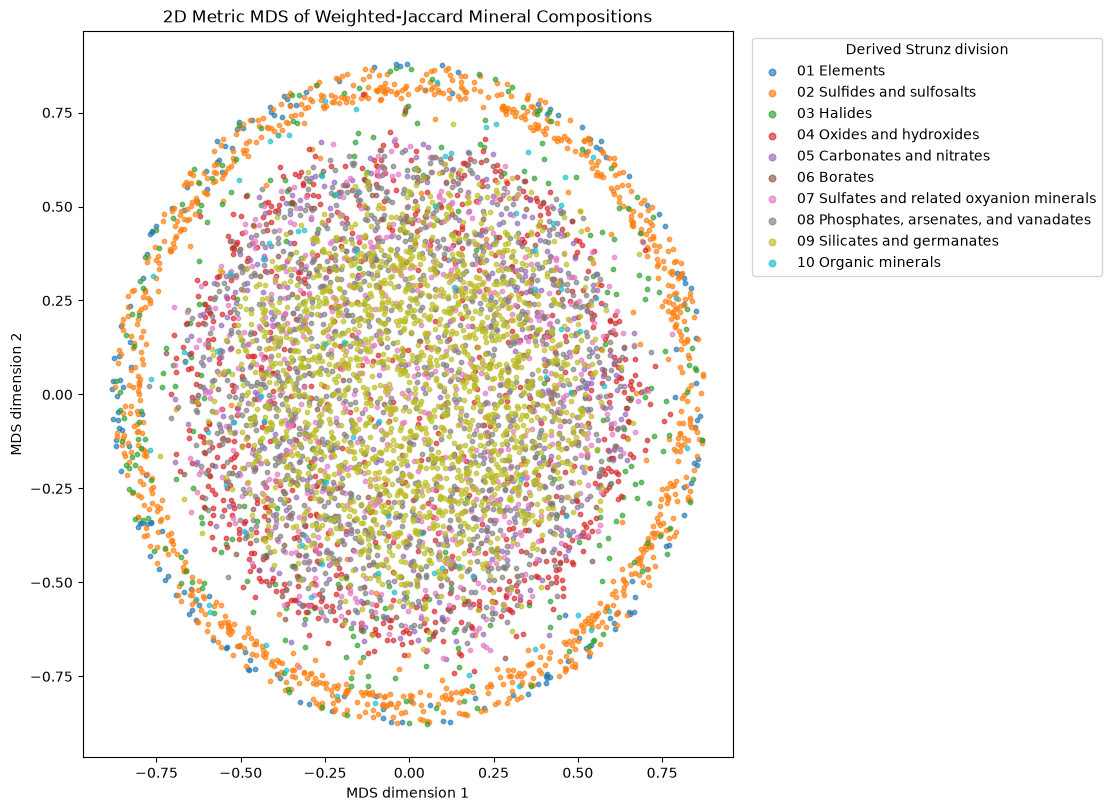

In [5]:
"""Prototype weighted-Jaccard composition similarity and 2D metric MDS."""

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import LinearOperator, eigsh
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances


ELEMENT_WEIGHTS = {"O": 0.25, "H": 0.15}
SPECTRUM_DIMENSIONS = 32
RANDOM_STATE = 42


def subscript_coefficient(value: str) -> float:
    """Convert a concise subscript to a usable molar coefficient.

    Fixed numeric values are preserved. Variable coefficients such as ``1-x``
    use their leading numeric term; unknown variables use 1.0 as a neutral
    starting approximation.
    """
    value = value.strip()
    if re.fullmatch(r"\d+(?:\.\d+)?", value):
        return float(value)
    fraction = re.fullmatch(r"(\d+(?:\.\d+)?)/(\d+(?:\.\d+)?)", value)
    if fraction:
        return float(fraction.group(1)) / float(fraction.group(2))
    leading_number = re.match(r"\d+(?:\.\d+)?", value)
    return float(leading_number.group()) if leading_number else 1.0


def concise_molar_composition(formula: str) -> Counter[str]:
    """Parse approximate element counts from concise chemistry markup.

    Charges and vacancies are ignored. Parenthesized/bracketed groups and their
    subscripts are expanded. Alternatives at a shared site are retained as a
    simple prototype representation rather than assigned occupancies.
    """
    formula = re.sub(r"\^[^^]*\^", "", formula)

    def read_subscript(position: int) -> tuple[float, int]:
        if position >= len(formula) or formula[position] != "_":
            return 1.0, position
        end = formula.find("_", position + 1)
        if end == -1:
            return 1.0, position + 1
        return subscript_coefficient(formula[position + 1 : end]), end + 1

    def parse_group(position: int, closing: str | None = None) -> tuple[Counter[str], int]:
        counts: Counter[str] = Counter()
        hydration_multiplier = 1.0
        while position < len(formula):
            character = formula[position]
            if closing and character == closing:
                return counts, position + 1
            if character in ".·":
                position += 1
                multiplier_match = re.match(r"\d+(?:\.\d+)?", formula[position:])
                if multiplier_match:
                    hydration_multiplier = float(multiplier_match.group())
                    position += len(multiplier_match.group())
                else:
                    hydration_multiplier = 1.0
                continue
            if character in "([{":
                close_character = {"(": ")", "[": "]", "{": "}"}[character]
                nested_counts, position = parse_group(position + 1, close_character)
                multiplier, position = read_subscript(position)
                for element, count in nested_counts.items():
                    counts[element] += hydration_multiplier * multiplier * count
                continue
            if character.isupper():
                symbol = next(
                    (candidate for candidate in SYMBOLS_BY_LENGTH if formula.startswith(candidate, position)),
                    None,
                )
                if symbol is not None:
                    position += len(symbol)
                    multiplier, position = read_subscript(position)
                    counts[symbol] += hydration_multiplier * multiplier
                    continue
            position += 1
        return counts, position

    return parse_group(0)[0]


molar_compositions = [
    concise_molar_composition(row["Valence Chemistry (concise)"])
    for row in rows_with_derived_strunz
]
composition_elements = sorted({element for composition in molar_compositions for element in composition})
element_index = {element: index for index, element in enumerate(composition_elements)}
molar_matrix = np.zeros((len(molar_compositions), len(composition_elements)), dtype=np.float32)
for mineral_index, composition in enumerate(molar_compositions):
    for element, count in composition.items():
        molar_matrix[mineral_index, element_index[element]] = count

mole_fractions = molar_matrix / molar_matrix.sum(axis=1, keepdims=True)
element_weight_vector = np.array(
    [ELEMENT_WEIGHTS.get(element, 1.0) for element in composition_elements], dtype=np.float32
)
weighted_mole_fractions = mole_fractions * element_weight_vector
weighted_totals = weighted_mole_fractions.sum(axis=1)

# min(a, b) and max(a, b) are derived from L1 distance, avoiding an n x n x m tensor.
composition_distances = pairwise_distances(weighted_mole_fractions, metric="manhattan").astype(np.float32)
combined_totals = weighted_totals[:, None] + weighted_totals[None, :]
composition_distances *= 2.0 / (combined_totals + composition_distances)
np.fill_diagonal(composition_distances, 0.0)
del combined_totals


def classical_gram_matvec(vector: np.ndarray) -> np.ndarray:
    """Apply the doubly centered classical-MDS Gram matrix without materializing it."""
    centered_vector = vector - vector.mean()
    result = -0.5 * (squared_distances @ centered_vector)
    return result - result.mean()


squared_distances = np.square(composition_distances, dtype=np.float32)
number_of_minerals = composition_distances.shape[0]
leading_count = min(SPECTRUM_DIMENSIONS, number_of_minerals - 1)
classical_gram_operator = LinearOperator(
    (number_of_minerals, number_of_minerals),
    matvec=classical_gram_matvec,
    dtype=np.float64,
)
leading_eigenvalues, leading_eigenvectors = eigsh(
    classical_gram_operator,
    k=leading_count,
    which="LA",
    tol=1e-5,
    v0=np.random.default_rng(RANDOM_STATE).normal(size=number_of_minerals),
)
order = np.argsort(leading_eigenvalues)[::-1]
leading_eigenvalues = leading_eigenvalues[order]
leading_eigenvectors = leading_eigenvectors[:, order]
positive_eigenvalues = leading_eigenvalues[leading_eigenvalues > 1e-8]
leading_variance_explained = positive_eigenvalues / positive_eigenvalues.sum()
leading_cumulative_variance = np.cumsum(leading_variance_explained)

spectrum_table = [
    {
        "dimension": dimension,
        "eigenvalue": eigenvalue,
        "captured_positive_variance": variance,
        "captured_cumulative_variance": cumulative,
    }
    for dimension, (eigenvalue, variance, cumulative) in enumerate(
        zip(positive_eigenvalues, leading_variance_explained, leading_cumulative_variance), start=1
    )
]

print(
    f"Parsed {len(composition_elements)} elements for {number_of_minerals:,} minerals. "
    f"O weight={ELEMENT_WEIGHTS['O']}, H weight={ELEMENT_WEIGHTS['H']}."
)
print(
    "Leading classical-MDS positive eigenvalue spectrum "
    f"(first {len(positive_eigenvalues)} dimensions; shares are within this captured spectrum):"
)
for entry in spectrum_table[:10]:
    print(
        f"  {entry['dimension']:>2}: eigenvalue={entry['eigenvalue']:.5f}, "
        f"variance={entry['captured_positive_variance']:.2%}, "
        f"cumulative={entry['captured_cumulative_variance']:.2%}"
    )
if len(leading_cumulative_variance) >= 3:
    print(
        f"\nCaptured spectrum: 2D={leading_cumulative_variance[1]:.2%}; "
        f"3D={leading_cumulative_variance[2]:.2%}; "
        f"increment from dimension 3={leading_variance_explained[2]:.2%}."
    )

metric_mds = MDS(
    n_components=2,
    metric_mds=True,
    metric="precomputed",
    init="random",
    n_init=1,
    max_iter=100,
    eps=1e-3,
    random_state=RANDOM_STATE,
)
metric_mds_coordinates = metric_mds.fit_transform(composition_distances)
print(f"\n2D metric-MDS stress: {metric_mds.stress_:.4f}")

fig, axis = plt.subplots(figsize=(11, 8), constrained_layout=True)
strunz_labels = [row[DERIVED_COLUMN] for row in rows_with_derived_strunz]
for division in sorted(STRUNZ_TOP_LEVEL_NAMES):
    mask = np.array([label == division for label in strunz_labels])
    axis.scatter(
        metric_mds_coordinates[mask, 0],
        metric_mds_coordinates[mask, 1],
        s=10,
        alpha=0.65,
        label=f"{division} {STRUNZ_TOP_LEVEL_NAMES[division]}",
        rasterized=True,
    )
axis.set_title("2D Metric MDS of Weighted-Jaccard Mineral Compositions")
axis.set_xlabel("MDS dimension 1")
axis.set_ylabel("MDS dimension 2")
axis.legend(title="Derived Strunz division", bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=1.5)
plt.show()

## Transport Model Notes

- Formula features are valence-resolved: an omitted oxidation state remains `Element^?`; it is never inferred from charge balance. This preserves redox differences and avoids turning incomplete source data into a silent claim.
- Transport never crosses cation and anion sublattices. Each EMD is solved separately, so cation substitution cannot compensate for an anion-framework difference.
- The element ground cost is a hand-authored Goldschmidt-style substitution model, not a generic one-dimensional elemental scale. Low-cost families encode alkalis, alkaline earths, divalent transition metals, trivalent substitutions, rare-earth elements, halides, and related oxyanion formers.
- The initial two-sublattice EMD is retained as a prototype/reference. The later additive metric is the visualization model because it exposes named distance contributions.

In [6]:
"""Valence-resolved Element Mover's Distance with separate sublattice transport."""

import ot


# Missing oxidation states remain explicit Element^? features. This prototype does
# not infer them from charge balance, so unresolved and resolved redox states cannot
# silently collapse into one feature.
ANION_BY_CONVENTION = frozenset({"O", "F", "Cl", "Br", "I", "S", "Se", "Te", "N", "C"})
OXYANION_FORMERS = frozenset({"B", "Si", "P", "As", "V", "Cr", "Mo", "W", "Se", "Te", "S"})

# Each family implements a Goldschmidt-compatible substitution neighborhood rather
# than projecting elements onto an off-the-shelf one-dimensional elemental scale.
SUBSTITUTION_FAMILIES = (
    frozenset({"Li", "Na", "K", "Rb", "Cs"}),
    frozenset({"Be", "Mg", "Ca", "Sr", "Ba"}),
    frozenset({"Mg", "Fe", "Mn", "Co", "Ni", "Zn", "Cd"}),
    frozenset({"Al", "Fe", "Cr", "Ga", "Sc", "In"}),
    frozenset({"Ti", "Zr", "Hf"}),
    frozenset({"V", "Nb", "Ta"}),
    frozenset({"Y", "La", "Ce", "Pr", "Nd", "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb", "Lu"}),
    frozenset({"F", "Cl", "Br", "I"}),
    frozenset({"O", "S", "Se", "Te"}),
    frozenset({"P", "As", "V"}),
    frozenset({"Cr", "Mo", "W"}),
)


def parse_feature_label(feature: str) -> tuple[str, str]:
    """Split a valence-resolved feature into element and oxidation-state label."""
    element, separator, state = feature.partition("^")
    return element, state if separator else "?"


def oxidation_number(state: str) -> int | None:
    """Convert a normalized state such as ``2+`` to an integer when known."""
    if state == "?":
        return None
    magnitude = int(state[:-1])
    return magnitude if state.endswith("+") else -magnitude


def feature_sublattice(feature: str) -> str:
    """Assign a feature to cation or anion transport without cross-sublattice flow.

    Negatively charged species are anions. High-valence oxyanion formers remain
    with the anion framework even though their formal oxidation number is positive.
    """
    element, state = parse_feature_label(feature)
    oxidation = oxidation_number(state)
    if oxidation is not None and oxidation < 0:
        return "anion"
    if element in OXYANION_FORMERS and (oxidation is None or oxidation >= 3):
        return "anion"
    if element in ANION_BY_CONVENTION:
        return "anion"
    return "cation"


def valence_resolved_molar_composition(formula: str) -> Counter[str]:
    """Parse approximate molar counts into valence-resolved formula features."""

    def read_subscript(position: int) -> tuple[float, int]:
        if position >= len(formula) or formula[position] != "_":
            return 1.0, position
        end = formula.find("_", position + 1)
        if end == -1:
            return 1.0, position + 1
        return subscript_coefficient(formula[position + 1 : end]), end + 1

    def read_feature(position: int) -> tuple[str | None, int]:
        element = next(
            (candidate for candidate in SYMBOLS_BY_LENGTH if formula.startswith(candidate, position)),
            None,
        )
        if element is None:
            return None, position
        position += len(element)
        state = "?"
        if position < len(formula) and formula[position] == "^":
            charge_end = formula.find("^", position + 1)
            if charge_end != -1:
                normalized_charge = normalize_charge(formula[position + 1 : charge_end])
                if normalized_charge is not None:
                    state = normalized_charge
                    position = charge_end + 1
        return f"{element}^{state}", position

    def parse_group(position: int, closing: str | None = None) -> tuple[Counter[str], int]:
        counts: Counter[str] = Counter()
        hydration_multiplier = 1.0
        while position < len(formula):
            character = formula[position]
            if closing and character == closing:
                return counts, position + 1
            if character in ".·":
                position += 1
                multiplier_match = re.match(r"\d+(?:\.\d+)?", formula[position:])
                if multiplier_match:
                    hydration_multiplier = float(multiplier_match.group())
                    position += len(multiplier_match.group())
                else:
                    hydration_multiplier = 1.0
                continue
            if character in "([{":
                close_character = {"(": ")", "[": "]", "{": "}"}[character]
                nested_counts, position = parse_group(position + 1, close_character)
                multiplier, position = read_subscript(position)
                for feature, count in nested_counts.items():
                    counts[feature] += hydration_multiplier * multiplier * count
                continue
            if character.isupper():
                feature, next_position = read_feature(position)
                if feature is not None:
                    position = next_position
                    multiplier, position = read_subscript(position)
                    counts[feature] += hydration_multiplier * multiplier
                    continue
            position += 1
        return counts, position

    return parse_group(0)[0]


def same_substitution_family(element_a: str, element_b: str) -> bool:
    """Return whether two elements share one explicit substitution neighborhood."""
    return any(element_a in family and element_b in family for family in SUBSTITUTION_FAMILIES)


def goldschmidt_ground_cost(feature_a: str, feature_b: str) -> float:
    """Return a bounded, rule-based transport cost within one sublattice."""
    if feature_a == feature_b:
        return 0.0
    element_a, state_a = parse_feature_label(feature_a)
    element_b, state_b = parse_feature_label(feature_b)
    oxidation_a = oxidation_number(state_a)
    oxidation_b = oxidation_number(state_b)

    if same_substitution_family(element_a, element_b):
        cost = 0.12
    elif element_a == element_b:
        cost = 0.35
    else:
        cost = 0.85

    if oxidation_a is None or oxidation_b is None:
        cost += 0.10
    elif oxidation_a != oxidation_b:
        cost += 0.18 + 0.12 * min(abs(oxidation_a - oxidation_b), 3)
    return min(cost, 1.5)


def transport_distribution(
    composition: Counter[str], sublattice: str
) -> tuple[list[str], np.ndarray]:
    """Extract a normalized mass distribution for one sublattice."""
    features = sorted(feature for feature in composition if feature_sublattice(feature) == sublattice)
    masses = np.array([composition[feature] for feature in features], dtype=float)
    return features, masses / masses.sum() if len(masses) else masses


def element_movers_distance(
    composition_a: Counter[str], composition_b: Counter[str], anion_weight: float = 0.5
) -> dict[str, float]:
    """Compute independent cation/anion EMD values and their weighted combination."""
    distances: dict[str, float] = {}
    for sublattice in ("cation", "anion"):
        features_a, masses_a = transport_distribution(composition_a, sublattice)
        features_b, masses_b = transport_distribution(composition_b, sublattice)
        if not len(features_a) and not len(features_b):
            distances[sublattice] = 0.0
            continue
        if not len(features_a) or not len(features_b):
            distances[sublattice] = 1.5
            continue
        cost_matrix = np.array(
            [[goldschmidt_ground_cost(feature_a, feature_b) for feature_b in features_b] for feature_a in features_a]
        )
        distances[sublattice] = float(ot.emd2(masses_a, masses_b, cost_matrix))

    distances["combined"] = (
        (1.0 - anion_weight) * distances["cation"] + anion_weight * distances["anion"]
    )
    return distances


valence_resolved_compositions = [
    valence_resolved_molar_composition(row["Valence Chemistry (concise)"])
    for row in rows_with_derived_strunz
]
transport_features = sorted({feature for composition in valence_resolved_compositions for feature in composition})
feature_sublattices = Counter(feature_sublattice(feature) for feature in transport_features)
unknown_valence_features = sorted(feature for feature in transport_features if feature.endswith("^?"))

minerals_by_casefolded_name = {
    row["Mineral Name"].casefold(): composition
    for row, composition in zip(rows_with_derived_strunz, valence_resolved_compositions)
}
reference_pairs = (("Periclase", "Wüstite"), ("Wüstite", "Magnetite"), ("Magnetite", "Hematite"))
transport_examples = {}
for name_a, name_b in reference_pairs:
    composition_a = minerals_by_casefolded_name.get(name_a.casefold())
    composition_b = minerals_by_casefolded_name.get(name_b.casefold())
    if composition_a is not None and composition_b is not None:
        transport_examples[f"{name_a} - {name_b}"] = element_movers_distance(composition_a, composition_b)

print(
    f"Valence-resolved transport space: {len(transport_features)} features "
    f"({feature_sublattices['cation']} cation, {feature_sublattices['anion']} anion); "
    f"{len(unknown_valence_features)} retain an explicit ^? state."
)
print("Reference transport distances:")
for pair, distance in transport_examples.items():
    print(f"  {pair}: cation={distance['cation']:.3f}, anion={distance['anion']:.3f}, combined={distance['combined']:.3f}")

Valence-resolved transport space: 174 features (121 cation, 53 anion); 69 retain an explicit ^? state.
Reference transport distances:
  Periclase - Wüstite: cation=0.220, anion=0.000, combined=0.110
  Wüstite - Magnetite: cation=0.280, anion=0.000, combined=0.140
  Magnetite - Hematite: cation=0.140, anion=0.000, combined=0.070


Completed 8 of 256 landmark distance columns.
Completed 16 of 256 landmark distance columns.
Completed 24 of 256 landmark distance columns.
Completed 32 of 256 landmark distance columns.
Completed 40 of 256 landmark distance columns.
Completed 48 of 256 landmark distance columns.
Completed 56 of 256 landmark distance columns.
Completed 64 of 256 landmark distance columns.
Completed 72 of 256 landmark distance columns.
Completed 80 of 256 landmark distance columns.
Completed 88 of 256 landmark distance columns.
Completed 96 of 256 landmark distance columns.
Completed 104 of 256 landmark distance columns.
Completed 112 of 256 landmark distance columns.
Completed 120 of 256 landmark distance columns.
Completed 128 of 256 landmark distance columns.
Completed 136 of 256 landmark distance columns.
Completed 144 of 256 landmark distance columns.
Completed 152 of 256 landmark distance columns.
Completed 160 of 256 landmark distance columns.
Completed 168 of 256 landmark distance columns.
Compl

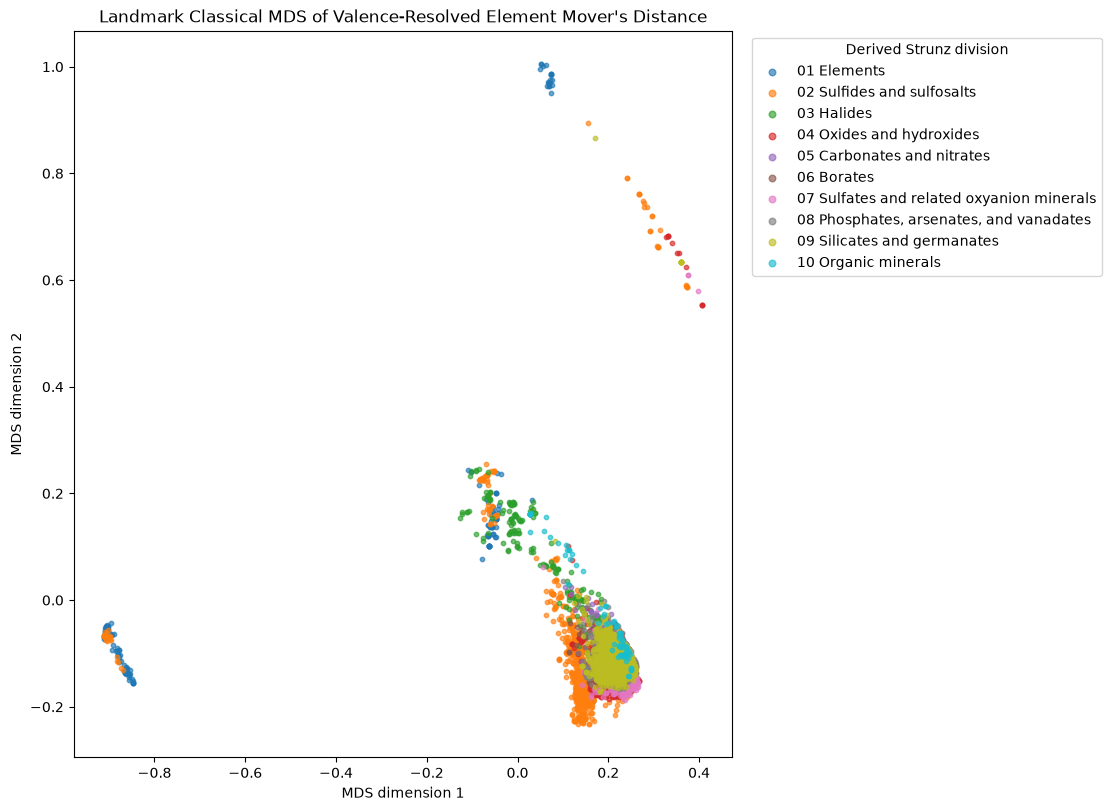

In [7]:
"""Landmark classical MDS from exact valence-resolved transport distances."""

from joblib import Parallel, delayed
from numpy.lib.format import open_memmap
import os


LANDMARK_COUNT = 256
LANDMARK_RANDOM_STATE = 42
LANDMARK_BATCH_SIZE = min(8, os.cpu_count() or 1)
LANDMARK_WORKERS = min(8, os.cpu_count() or 1)
LANDMARK_INDEX_PATH = Path(f"transport_landmark_indices_{LANDMARK_COUNT}.npy")
LANDMARK_DISTANCE_PATH = Path(f"transport_landmark_distances_{LANDMARK_COUNT}.npy")


def stratified_farthest_point_landmarks(
    candidate_distances: np.ndarray, labels: list[str], landmark_count: int, random_state: int
) -> np.ndarray:
    """Seed each Strunz class, then greedily maximize minimum Jaccard distance."""
    if landmark_count > len(labels):
        raise ValueError("Landmark count cannot exceed the number of minerals.")
    generator = np.random.default_rng(random_state)
    labels_array = np.asarray(labels)
    selected = [
        int(generator.choice(np.flatnonzero(labels_array == label)))
        for label in np.unique(labels_array)
    ]
    minimum_distances = candidate_distances[:, selected].min(axis=1)
    minimum_distances[selected] = -np.inf
    while len(selected) < landmark_count:
        selected_index = int(np.argmax(minimum_distances))
        selected.append(selected_index)
        minimum_distances = np.minimum(minimum_distances, candidate_distances[:, selected_index])
        minimum_distances[selected] = -np.inf
    return np.array(selected, dtype=np.int32)


def precompute_transport_supports(
    compositions: list[Counter[str]], sublattice: str
) -> tuple[list[np.ndarray], list[np.ndarray], np.ndarray]:
    """Index normalized sparse feature masses against one global ground-cost matrix."""
    features = sorted(
        {feature for composition in compositions for feature in composition if feature_sublattice(feature) == sublattice}
    )
    feature_indices = {feature: index for index, feature in enumerate(features)}
    ground_cost = np.array(
        [[goldschmidt_ground_cost(left, right) for right in features] for left in features], dtype=np.float64
    )
    support_indices: list[np.ndarray] = []
    support_masses: list[np.ndarray] = []
    for composition in compositions:
        active_features, masses = transport_distribution(composition, sublattice)
        support_indices.append(np.array([feature_indices[feature] for feature in active_features], dtype=np.int16))
        support_masses.append(masses)
    return support_indices, support_masses, ground_cost


def exact_transport_component(
    source_indices: np.ndarray,
    source_masses: np.ndarray,
    target_indices: np.ndarray,
    target_masses: np.ndarray,
    ground_cost: np.ndarray,
) -> float:
    """Solve one exact EMD component on the active feature supports only."""
    if not len(source_indices) and not len(target_indices):
        return 0.0
    if not len(source_indices) or not len(target_indices):
        return 1.5
    active_cost = ground_cost[np.ix_(source_indices, target_indices)]
    return float(ot.emd2(source_masses, target_masses, active_cost, check_marginals=False, numThreads=1))


strunz_labels_array = np.array([row[DERIVED_COLUMN] for row in rows_with_derived_strunz])
landmark_indices = stratified_farthest_point_landmarks(
    composition_distances, strunz_labels_array.tolist(), LANDMARK_COUNT, LANDMARK_RANDOM_STATE
)

if LANDMARK_INDEX_PATH.exists():
    cached_indices = np.load(LANDMARK_INDEX_PATH)
    if not np.array_equal(cached_indices, landmark_indices):
        raise ValueError(f"Cached landmark indices in {LANDMARK_INDEX_PATH} do not match this configuration.")
else:
    np.save(LANDMARK_INDEX_PATH, landmark_indices)

cation_support_indices, cation_support_masses, cation_ground_cost = precompute_transport_supports(
    valence_resolved_compositions, "cation"
)
anion_support_indices, anion_support_masses, anion_ground_cost = precompute_transport_supports(
    valence_resolved_compositions, "anion"
)


def transport_distances_to_landmark(landmark_position: int) -> np.ndarray:
    """Return exact combined EMD from every mineral to one landmark."""
    landmark_index = landmark_indices[landmark_position]
    distances = np.empty(len(valence_resolved_compositions), dtype=np.float32)
    for mineral_index in range(len(valence_resolved_compositions)):
        cation_distance = exact_transport_component(
            cation_support_indices[mineral_index],
            cation_support_masses[mineral_index],
            cation_support_indices[landmark_index],
            cation_support_masses[landmark_index],
            cation_ground_cost,
        )
        anion_distance = exact_transport_component(
            anion_support_indices[mineral_index],
            anion_support_masses[mineral_index],
            anion_support_indices[landmark_index],
            anion_support_masses[landmark_index],
            anion_ground_cost,
        )
        distances[mineral_index] = 0.5 * (cation_distance + anion_distance)
    return distances


if LANDMARK_DISTANCE_PATH.exists():
    transport_distances_to_landmarks = np.load(LANDMARK_DISTANCE_PATH, mmap_mode="r+")
    if transport_distances_to_landmarks.shape != (len(rows_with_derived_strunz), LANDMARK_COUNT):
        raise ValueError(f"Cached landmark distances in {LANDMARK_DISTANCE_PATH} have the wrong shape.")
else:
    transport_distances_to_landmarks = open_memmap(
        LANDMARK_DISTANCE_PATH,
        mode="w+",
        dtype=np.float32,
        shape=(len(rows_with_derived_strunz), LANDMARK_COUNT),
    )
    transport_distances_to_landmarks[:] = np.nan
    transport_distances_to_landmarks.flush()

pending_landmarks = np.flatnonzero(np.isnan(transport_distances_to_landmarks[0]))
for batch_start in range(0, len(pending_landmarks), LANDMARK_BATCH_SIZE):
    batch = pending_landmarks[batch_start : batch_start + LANDMARK_BATCH_SIZE]
    batch_distances = Parallel(n_jobs=LANDMARK_WORKERS, prefer="threads")(
        delayed(transport_distances_to_landmark)(int(position)) for position in batch
    )
    for position, distances in zip(batch, batch_distances):
        transport_distances_to_landmarks[:, position] = distances
    transport_distances_to_landmarks.flush()
    print(f"Completed {batch_start + len(batch):,} of {len(pending_landmarks):,} landmark distance columns.")

landmark_transport_distances = np.asarray(
    transport_distances_to_landmarks[landmark_indices, :], dtype=np.float64
)
landmark_transport_distances = 0.5 * (landmark_transport_distances + landmark_transport_distances.T)
np.fill_diagonal(landmark_transport_distances, 0.0)
landmark_squared_distances = np.square(landmark_transport_distances)
landmark_count = len(landmark_indices)
centering_matrix = np.eye(landmark_count) - np.ones((landmark_count, landmark_count)) / landmark_count
landmark_gram_matrix = -0.5 * centering_matrix @ landmark_squared_distances @ centering_matrix
landmark_eigenvalues, landmark_eigenvectors = np.linalg.eigh(landmark_gram_matrix)
landmark_order = np.argsort(landmark_eigenvalues)[::-1]
landmark_eigenvalues = landmark_eigenvalues[landmark_order]
landmark_eigenvectors = landmark_eigenvectors[:, landmark_order]

EIGENVALUE_TOLERANCE = max(1e-10, landmark_eigenvalues[0] * 1e-10)
positive_landmark_eigenvalues = landmark_eigenvalues[landmark_eigenvalues > EIGENVALUE_TOLERANCE]
negative_landmark_eigenvalues = landmark_eigenvalues[landmark_eigenvalues < -EIGENVALUE_TOLERANCE]
positive_inertia = positive_landmark_eigenvalues.sum()
negative_inertia = np.abs(negative_landmark_eigenvalues).sum()
landmark_variance_explained = positive_landmark_eigenvalues / positive_inertia
landmark_cumulative_variance = np.cumsum(landmark_variance_explained)

landmark_spectrum = [
    {
        "dimension": dimension,
        "eigenvalue": eigenvalue,
        "positive_variance": variance,
        "cumulative_positive_variance": cumulative,
    }
    for dimension, (eigenvalue, variance, cumulative) in enumerate(
        zip(positive_landmark_eigenvalues, landmark_variance_explained, landmark_cumulative_variance),
        start=1,
    )
]
non_euclidean_diagnostics = {
    "positive_eigenvalues": len(positive_landmark_eigenvalues),
    "negative_eigenvalues": len(negative_landmark_eigenvalues),
    "negative_inertia": float(negative_inertia),
    "negative_inertia_fraction": float(negative_inertia / (positive_inertia + negative_inertia)),
    "most_negative_eigenvalue": float(negative_landmark_eigenvalues.min()) if len(negative_landmark_eigenvalues) else 0.0,
}

embedding_dimensions = min(3, len(positive_landmark_eigenvalues))
landmark_coordinates = (
    landmark_eigenvectors[:, :embedding_dimensions] * np.sqrt(positive_landmark_eigenvalues[:embedding_dimensions])
)
# Gower interpolation places each non-landmark from its distances to the landmark basis.
landmark_column_means = landmark_squared_distances.mean(axis=0)
landmark_grand_mean = landmark_squared_distances.mean()
all_squared_distances_to_landmarks = np.square(np.asarray(transport_distances_to_landmarks, dtype=np.float64))
all_row_means = all_squared_distances_to_landmarks.mean(axis=1, keepdims=True)
all_centered_inner_products = -0.5 * (
    all_squared_distances_to_landmarks - all_row_means - landmark_column_means + landmark_grand_mean
)
landmark_projection = landmark_eigenvectors[:, :embedding_dimensions] / np.sqrt(
    positive_landmark_eigenvalues[:embedding_dimensions]
)
transport_landmark_coordinates = all_centered_inner_products @ landmark_projection

landmark_two_dimensional_distances = pairwise_distances(landmark_coordinates[:, :2])
landmark_two_dimensional_stress = float(
    np.sum((landmark_transport_distances - landmark_two_dimensional_distances) ** 2)
    / np.sum(landmark_transport_distances**2)
)

print(f"Exact transport distances: {len(rows_with_derived_strunz):,} minerals x {landmark_count:,} landmarks.")
print("Leading landmark classical-MDS spectrum:")
for entry in landmark_spectrum[:10]:
    print(
        f"  {entry['dimension']:>2}: eigenvalue={entry['eigenvalue']:.5f}, "
        f"variance={entry['positive_variance']:.2%}, "
        f"cumulative={entry['cumulative_positive_variance']:.2%}"
    )
print(
    f"2D={landmark_cumulative_variance[1]:.2%}; "
    f"3D={landmark_cumulative_variance[2]:.2%}; "
    f"third-dimension increment={landmark_variance_explained[2]:.2%}."
)
print(f"Landmark 2D normalized stress: {landmark_two_dimensional_stress:.4f}")
print(
    "Non-Euclidean diagnostic: "
    f"{non_euclidean_diagnostics['negative_eigenvalues']} negative eigenvalues; "
    f"negative inertia fraction={non_euclidean_diagnostics['negative_inertia_fraction']:.2%}; "
    f"most negative={non_euclidean_diagnostics['most_negative_eigenvalue']:.5f}."
)

fig, axis = plt.subplots(figsize=(11, 8), constrained_layout=True)
for division in sorted(STRUNZ_TOP_LEVEL_NAMES):
    division_mask = strunz_labels_array == division
    axis.scatter(
        transport_landmark_coordinates[division_mask, 0],
        transport_landmark_coordinates[division_mask, 1],
        s=10,
        alpha=0.65,
        label=f"{division} {STRUNZ_TOP_LEVEL_NAMES[division]}",
        rasterized=True,
    )
axis.set_title("Landmark Classical MDS of Valence-Resolved Element Mover's Distance")
axis.set_xlabel("MDS dimension 1")
axis.set_ylabel("MDS dimension 2")
axis.legend(title="Derived Strunz division", bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=1.5)
plt.show()

In [7]:
"""Explainable additive mineral dissimilarity with explicit formula-water handling."""

ADDITIVE_COMPONENT_WEIGHTS = {
    "anion_group": 0.43,
    "cations": 0.33,
    "extra_anions": 0.12,
    "hydration": 0.05,
    "structural_water": 0.05,
    "structure": 0.02,
}
assert np.isclose(sum(ADDITIVE_COMPONENT_WEIGHTS.values()), 1.0)

ANION_GROUP_PATTERN = re.compile(r"(?P<center>B|C|Si|P|S|As|Se|Te|V|Cr|Mo|W)O_(?P<oxygen>[^_]+)_")
PARENTHESIZED_ANION_GROUP_PATTERN = re.compile(
    r"[\(\[](?P<center>B|C|Si|P|S|As|Se|Te|V|Cr|Mo|W)O_(?P<oxygen>[^_]+)_[\)\]]"
    r"(?:_(?P<multiplicity>[^_]+)_)?"
)
DOTTED_WATER_PATTERN = re.compile(r"[.·](?P<count>\d+(?:\.\d+)?)?H_2_O")
STRUCTURAL_WATER_PATTERN = re.compile(r"[\(\[]H_2_O[\)\]](?:_(?P<multiplicity>[^_]+)_)?")
STRUCTURELESS_GROUPS = frozenset({"", "Not in a structural group"})


def concise_anion_groups(formula: str) -> Counter[str]:
    """Extract oxyanion groups, including a following parenthesized-group multiplier."""
    plain_formula = re.sub(r"\^[^^]*\^", "", formula)
    groups: Counter[str] = Counter()
    occupied_spans: list[tuple[int, int]] = []
    for match in PARENTHESIZED_ANION_GROUP_PATTERN.finditer(plain_formula):
        oxygen_count = subscript_coefficient(match["oxygen"])
        multiplicity = subscript_coefficient(match["multiplicity"] or "1")
        if oxygen_count > 0 and multiplicity > 0:
            groups[f"{match['center']}-O{oxygen_count:g}"] += multiplicity
            occupied_spans.append(match.span())
    for match in ANION_GROUP_PATTERN.finditer(plain_formula):
        if any(start <= match.start() < end for start, end in occupied_spans):
            continue
        oxygen_count = subscript_coefficient(match["oxygen"])
        if oxygen_count > 0:
            groups[f"{match['center']}-O{oxygen_count:g}"] += 1.0
    return groups


def group_label_parts(group_label: str) -> tuple[str, float]:
    """Return the central element and oxygen coordination from a group label."""
    center, oxygen = group_label.split("-O", maxsplit=1)
    return center, float(oxygen)


def anion_group_ground_cost(group_a: str, group_b: str) -> float:
    """Cost group substitution by central-element compatibility and coordination."""
    if group_a == group_b:
        return 0.0
    center_a, oxygen_a = group_label_parts(group_a)
    center_b, oxygen_b = group_label_parts(group_b)
    base_cost = 0.12 if same_substitution_family(center_a, center_b) else 0.85
    return min(1.5, base_cost + 0.12 * abs(oxygen_a - oxygen_b))


def normalized_counter(counter: Counter[str]) -> tuple[list[str], np.ndarray]:
    """Return sorted labels and normalized masses for a sparse component."""
    labels = sorted(counter)
    masses = np.array([counter[label] for label in labels], dtype=float)
    return labels, masses / masses.sum() if len(masses) else masses


def sparse_emd(labels_a: list[str], masses_a: np.ndarray, labels_b: list[str], masses_b: np.ndarray, ground_cost) -> float:
    """Evaluate exact EMD for a named sparse component, including empty cases."""
    if not len(labels_a) and not len(labels_b):
        return 0.0
    if not len(labels_a) or not len(labels_b):
        return 1.5
    cost_matrix = np.array([[ground_cost(left, right) for right in labels_b] for left in labels_a], dtype=float)
    return float(ot.emd2(masses_a, masses_b, cost_matrix, check_marginals=False, numThreads=1))


def hydration_amount(formula: str) -> float:
    """Return water of hydration specified after a dot separator."""
    plain_formula = re.sub(r"\^[^^]*\^", "", formula)
    return sum(float(match["count"] or 1.0) for match in DOTTED_WATER_PATTERN.finditer(plain_formula))


def structural_water_amount(formula: str) -> float:
    """Return parenthesized or bracketed H2O formula units as structural water."""
    plain_formula = re.sub(r"\^[^^]*\^", "", formula)
    return sum(subscript_coefficient(match["multiplicity"] or "1") for match in STRUCTURAL_WATER_PATTERN.finditer(plain_formula))


def formula_water_amount(formula: str) -> float:
    """Return all H2O units so water is not also compared as generic H and O."""
    return hydration_amount(formula) + structural_water_amount(formula)


def remove_element_mass(composition: Counter[str], element: str, amount: float) -> Counter[str]:
    """Remove formula-unit mass from matching valence features without going negative."""
    residual = Counter(composition)
    remaining = amount
    features = sorted(
        (feature for feature in residual if parse_feature_label(feature)[0] == element),
        key=lambda feature: (parse_feature_label(feature)[1] != "?", feature),
    )
    for feature in features:
        removed = min(residual[feature], remaining)
        residual[feature] -= removed
        remaining -= removed
        if remaining <= 1e-12:
            break
    return Counter({feature: count for feature, count in residual.items() if count > 1e-12})


def cation_composition(formula: str, composition: Counter[str]) -> Counter[str]:
    """Return cation chemistry after removing hydrogen allocated to formula water."""
    cations = Counter({feature: count for feature, count in composition.items() if feature_sublattice(feature) == "cation"})
    return remove_element_mass(cations, "H", 2.0 * formula_water_amount(formula))


def extra_anion_composition(formula: str, composition: Counter[str]) -> Counter[str]:
    """Retain residual anions after oxyanion groups and formula water are allocated."""
    residual = Counter({feature: count for feature, count in composition.items() if feature_sublattice(feature) == "anion"})
    for group, multiplicity in concise_anion_groups(formula).items():
        center, oxygen = group_label_parts(group)
        residual = remove_element_mass(residual, center, multiplicity)
        residual = remove_element_mass(residual, "O", multiplicity * oxygen)
    return remove_element_mass(residual, "O", formula_water_amount(formula))


def water_distance(amount_a: float, amount_b: float) -> float:
    """Bounded log-scale difference for a count of formula water units."""
    return min(1.0, abs(np.log1p(amount_a) - np.log1p(amount_b)) / np.log(25.0))


def structure_distance(row_a: dict[str, str], row_b: dict[str, str]) -> float:
    """Small categorical penalty that separates otherwise colliding polymorphs."""
    group_a = row_a["Structural Groupname"]
    group_b = row_b["Structural Groupname"]
    if group_a not in STRUCTURELESS_GROUPS and group_a == group_b:
        return 0.0
    if group_a in STRUCTURELESS_GROUPS or group_b in STRUCTURELESS_GROUPS:
        return 0.75
    if row_a["Crystal Systems"] == row_b["Crystal Systems"]:
        return 0.5
    return 1.0


def additive_component_profile(row: dict[str, str], composition: Counter[str]) -> dict[str, object]:
    """Construct independently comparable components for one mineral."""
    formula = row["Valence Chemistry (concise)"]
    cation_features, cation_masses = normalized_counter(cation_composition(formula, composition))
    extra_features, extra_masses = normalized_counter(extra_anion_composition(formula, composition))
    group_labels, group_masses = normalized_counter(concise_anion_groups(formula))
    return {
        "anion_group": (group_labels, group_masses),
        "cations": (cation_features, cation_masses),
        "extra_anions": (extra_features, extra_masses),
        "hydration": hydration_amount(formula),
        "structural_water": structural_water_amount(formula),
        "structure_row": row,
    }


def additive_mineral_distance(profile_a: dict[str, object], profile_b: dict[str, object]) -> dict[str, float]:
    """Return raw and weighted components whose contributions sum exactly."""
    group_a, group_masses_a = profile_a["anion_group"]
    group_b, group_masses_b = profile_b["anion_group"]
    cation_a, cation_masses_a = profile_a["cations"]
    cation_b, cation_masses_b = profile_b["cations"]
    extra_a, extra_masses_a = profile_a["extra_anions"]
    extra_b, extra_masses_b = profile_b["extra_anions"]
    raw_components = {
        "anion_group": sparse_emd(group_a, group_masses_a, group_b, group_masses_b, anion_group_ground_cost),
        "cations": sparse_emd(cation_a, cation_masses_a, cation_b, cation_masses_b, goldschmidt_ground_cost),
        "extra_anions": sparse_emd(extra_a, extra_masses_a, extra_b, extra_masses_b, goldschmidt_ground_cost),
        "hydration": water_distance(profile_a["hydration"], profile_b["hydration"]),
        "structural_water": water_distance(profile_a["structural_water"], profile_b["structural_water"]),
        "structure": structure_distance(profile_a["structure_row"], profile_b["structure_row"]),
    }
    weighted_components = {component: ADDITIVE_COMPONENT_WEIGHTS[component] * value for component, value in raw_components.items()}
    return {**{f"raw_{component}": value for component, value in raw_components.items()}, **weighted_components, "total": sum(weighted_components.values())}


def relationship_taxonomy(distance: dict[str, float], row_a: dict[str, str], row_b: dict[str, str]) -> str:
    """Assign a concise relationship label from raw additive components."""
    near_zero = lambda component: distance[f"raw_{component}"] <= 0.02
    same_group = row_a["Structural Groupname"] not in STRUCTURELESS_GROUPS and row_a["Structural Groupname"] == row_b["Structural Groupname"]
    if near_zero("cations") and near_zero("extra_anions") and near_zero("hydration") and near_zero("structural_water") and same_group:
        return f"Anion-group analogues. Both members of the {row_a['Structural Groupname']} group."
    if near_zero("anion_group") and near_zero("extra_anions") and near_zero("hydration") and near_zero("structural_water") and same_group:
        return f"Cation-substitution analogues. Both members of the {row_a['Structural Groupname']} group."
    if all(near_zero(component) for component in ("anion_group", "cations", "extra_anions", "hydration", "structural_water")):
        return "Compositionally coincident; separated only by the structure component."
    dominant_component = max(ADDITIVE_COMPONENT_WEIGHTS, key=lambda component: distance[component])
    return f"Primarily differentiated by {dominant_component.replace('_', ' ')}."


additive_profiles = [additive_component_profile(row, composition) for row, composition in zip(rows_with_derived_strunz, valence_resolved_compositions)]
profiles_by_name = {row["Mineral Name"].casefold(): (row, profile) for row, profile in zip(rows_with_derived_strunz, additive_profiles)}


def explain_relationship(name_a: str, name_b: str) -> dict[str, object]:
    """Return component values and a relationship taxonomy label."""
    row_a, profile_a = profiles_by_name[name_a.casefold()]
    row_b, profile_b = profiles_by_name[name_b.casefold()]
    distance = additive_mineral_distance(profile_a, profile_b)
    return {
        "minerals": (row_a["Mineral Name"], row_b["Mineral Name"]),
        "relationship": relationship_taxonomy(distance, row_a, row_b),
        "weighted_components": {component: distance[component] for component in ADDITIVE_COMPONENT_WEIGHTS},
        "raw_components": {component: distance[f"raw_{component}"] for component in ADDITIVE_COMPONENT_WEIGHTS},
        "total_distance": distance["total"],
    }


apatite_analogue_example = explain_relationship("Pyromorphite", "Mimetite")
print(apatite_analogue_example["relationship"])
print(f"Total additive distance: {apatite_analogue_example['total_distance']:.4f}")
for component, contribution in apatite_analogue_example["weighted_components"].items():
    print(f"  {component.replace('_', ' '):<16} {contribution:.4f}")

Anion-group analogues. Both members of the Apatite group.
Total additive distance: 0.0516
  anion group      0.0516
  cations          0.0000
  extra anions     0.0000
  hydration        0.0000
  structural water 0.0000
  structure        0.0000


## Additive Distance Notes

The production dissimilarity is a fixed, chemistry-first additive decomposition over `anion_group`, `cations`, `extra_anions`, `hydration`, `structural_water`, and `structure`.

- Oxyanion groups are named formula units and are removed from residual anion mass.
- Dotted water such as `·2H2O` is hydration. Parenthesized or bracketed `H2O` is structural water. Both are removed from generic H/O comparison, so neither is double-counted.
- The structural-water term is deliberately distinct from hydration and modestly weighted: it preserves a meaningful constitutional distinction without becoming the primary map geometry.
- Production weights are not fitted to maximize 2D/3D projection quality. Weight sensitivity is reported as a diagnostic, while the fixed chemistry-first prior defines the map.
- Additive landmarks are selected under the same production dissimilarity and each cache is validated against a manifest containing source and model fingerprints.

In [13]:
"""Build a chemistry-first additive landmark model with reproducible caches."""

import hashlib
import json


CACHE_SCHEMA_VERSION = "additive-landmark-v3"
VISUALIZATION_LANDMARK_COUNT = 512
TUNING_RANDOM_STATE = 42
COMPONENT_NAMES = tuple(ADDITIVE_COMPONENT_WEIGHTS)
BASELINE_WEIGHTS = np.array([ADDITIVE_COMPONENT_WEIGHTS[component] for component in COMPONENT_NAMES], dtype=float)
LANDMARK_CACHE_PATH = Path(f"additive_landmark_indices_{VISUALIZATION_LANDMARK_COUNT}_v3.npy")
COMPONENT_CACHE_PATH = Path(f"additive_component_distances_{VISUALIZATION_LANDMARK_COUNT}_v3.npz")
CACHE_MANIFEST_PATH = Path(f"additive_landmark_cache_{VISUALIZATION_LANDMARK_COUNT}_v3.json")
strunz_labels_array = np.asarray([row[DERIVED_COLUMN] for row in rows_with_derived_strunz])


def cache_manifest() -> dict[str, object]:
    """Fingerprint source records and every configuration affecting cached distances."""
    source_rows = [
        {
            "name": row["Mineral Name"],
            "formula": row["Valence Chemistry (concise)"],
            "valence_elements": row["Valence Elements"],
            "structural_group": row["Structural Groupname"],
            "crystal_system": row["Crystal Systems"],
            "derived_strunz": row[DERIVED_COLUMN],
        }
        for row in rows_with_derived_strunz
    ]
    source_hash = hashlib.sha256(json.dumps(source_rows, sort_keys=True, separators=(",", ":")).encode()).hexdigest()
    return {
        "schema_version": CACHE_SCHEMA_VERSION,
        "source_hash": source_hash,
        "landmark_count": VISUALIZATION_LANDMARK_COUNT,
        "component_names": list(COMPONENT_NAMES),
        "component_weights": dict(zip(COMPONENT_NAMES, map(float, BASELINE_WEIGHTS))),
        "formula_water_policy": "dotted water is hydration; parenthesized/bracketed water is structural water",
    }


def cache_is_valid(manifest: dict[str, object]) -> bool:
    """Accept a cache only when its manifest, shape, and component keys match."""
    if not all(path.exists() for path in (LANDMARK_CACHE_PATH, COMPONENT_CACHE_PATH, CACHE_MANIFEST_PATH)):
        return False
    try:
        cached_manifest = json.loads(CACHE_MANIFEST_PATH.read_text(encoding="utf-8"))
        cached_indices = np.load(LANDMARK_CACHE_PATH)
        with np.load(COMPONENT_CACHE_PATH) as cached:
            expected_shape = (len(additive_profiles), VISUALIZATION_LANDMARK_COUNT)
            valid_shapes = all(component in cached and cached[component].shape == expected_shape for component in COMPONENT_NAMES)
        return cached_manifest == manifest and cached_indices.shape == (VISUALIZATION_LANDMARK_COUNT,) and valid_shapes
    except (OSError, ValueError, json.JSONDecodeError):
        return False


def component_distance_column(landmark_index: int) -> dict[str, np.ndarray]:
    """Calculate raw additive components from every mineral to one landmark."""
    landmark_profile = additive_profiles[landmark_index]
    columns = {component: np.empty(len(additive_profiles), dtype=np.float32) for component in COMPONENT_NAMES}
    for mineral_index, mineral_profile in enumerate(additive_profiles):
        distance = additive_mineral_distance(mineral_profile, landmark_profile)
        for component in COMPONENT_NAMES:
            columns[component][mineral_index] = distance[f"raw_{component}"]
    return columns


def stratified_additive_landmarks() -> tuple[np.ndarray, dict[str, np.ndarray]]:
    """Seed divisions, then maximize minimum baseline additive distance."""
    generator = np.random.default_rng(TUNING_RANDOM_STATE)
    selected = [
        int(generator.choice(np.flatnonzero(strunz_labels_array == division)))
        for division in sorted(np.unique(strunz_labels_array))
    ]
    matrices = {
        component: np.empty((len(additive_profiles), VISUALIZATION_LANDMARK_COUNT), dtype=np.float32)
        for component in COMPONENT_NAMES
    }
    minimum_distances = np.full(len(additive_profiles), np.inf, dtype=float)
    for position in range(VISUALIZATION_LANDMARK_COUNT):
        if position >= len(selected):
            selected.append(int(np.argmax(minimum_distances)))
        columns = component_distance_column(selected[position])
        for component in COMPONENT_NAMES:
            matrices[component][:, position] = columns[component]
        combined = sum(BASELINE_WEIGHTS[index] * columns[component] for index, component in enumerate(COMPONENT_NAMES))
        minimum_distances = np.minimum(minimum_distances, combined)
        minimum_distances[np.asarray(selected, dtype=int)] = -np.inf
        if (position + 1) % 8 == 0 or position + 1 == VISUALIZATION_LANDMARK_COUNT:
            print(f"Completed {position + 1:,} of {VISUALIZATION_LANDMARK_COUNT:,} additive landmark columns.")
    return np.asarray(selected, dtype=np.int32), matrices


def classical_mds_diagnostics(distance_matrix: np.ndarray) -> dict[str, object]:
    """Return the positive spectrum and negative-inertia diagnostic."""
    count = len(distance_matrix)
    centering = np.eye(count) - np.ones((count, count)) / count
    gram = -0.5 * centering @ np.square(distance_matrix) @ centering
    eigenvalues, eigenvectors = np.linalg.eigh(gram)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    tolerance = max(1e-10, eigenvalues[0] * 1e-10)
    positive, negative = eigenvalues[eigenvalues > tolerance], eigenvalues[eigenvalues < -tolerance]
    positive_inertia, negative_inertia = positive.sum(), np.abs(negative).sum()
    variance = positive / positive_inertia
    return {
        "eigenvalues": eigenvalues,
        "eigenvectors": eigenvectors,
        "positive": positive,
        "negative": negative,
        "variance": variance,
        "cumulative_variance": np.cumsum(variance),
        "negative_inertia_fraction": negative_inertia / (positive_inertia + negative_inertia),
    }


def weighted_landmark_distances(component_matrices: dict[str, np.ndarray], weights: np.ndarray, landmark_indices: np.ndarray) -> np.ndarray:
    """Combine raw component matrices into a symmetric landmark distance matrix."""
    combined = sum(weights[index] * component_matrices[component] for index, component in enumerate(COMPONENT_NAMES))
    distances = np.asarray(combined[landmark_indices, :], dtype=np.float64)
    distances = 0.5 * (distances + distances.T)
    np.fill_diagonal(distances, 0.0)
    return distances


manifest = cache_manifest()
if cache_is_valid(manifest):
    visualization_landmark_indices = np.load(LANDMARK_CACHE_PATH)
    with np.load(COMPONENT_CACHE_PATH) as cached:
        visualization_component_matrices = {component: cached[component] for component in COMPONENT_NAMES}
    print(f"Loaded validated additive landmark cache: {COMPONENT_CACHE_PATH}")
else:
    visualization_landmark_indices, visualization_component_matrices = stratified_additive_landmarks()
    np.save(LANDMARK_CACHE_PATH, visualization_landmark_indices)
    np.savez_compressed(COMPONENT_CACHE_PATH, **visualization_component_matrices)
    CACHE_MANIFEST_PATH.write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")
    print(f"Built additive landmark cache: {COMPONENT_CACHE_PATH}")

# Production weights are chemistry-first priors, not projection-optimized parameters.
selected_weights = BASELINE_WEIGHTS.copy()
selected_component_weights = dict(zip(COMPONENT_NAMES, map(float, selected_weights)))
visualization_all_distances_to_landmarks = sum(
    selected_weights[index] * visualization_component_matrices[component]
    for index, component in enumerate(COMPONENT_NAMES)
).astype(np.float64)
selected_landmark_distances = weighted_landmark_distances(
    visualization_component_matrices, selected_weights, visualization_landmark_indices
)
selected_diagnostics = classical_mds_diagnostics(selected_landmark_distances)
positive_selected_eigenvalues = selected_diagnostics["positive"]
selected_variance_explained = selected_diagnostics["variance"]
selected_cumulative_variance = selected_diagnostics["cumulative_variance"]
selected_eigenvectors = selected_diagnostics["eigenvectors"][:, : len(positive_selected_eigenvalues)]

embedding_dimensions = 3
landmark_coordinates = selected_eigenvectors[:, :embedding_dimensions] * np.sqrt(positive_selected_eigenvalues[:embedding_dimensions])
selected_squared_distances = np.square(visualization_all_distances_to_landmarks)
selected_landmark_squared_distances = np.square(selected_landmark_distances)
selected_inner_products = -0.5 * (
    selected_squared_distances
    - selected_squared_distances.mean(axis=1, keepdims=True)
    - selected_landmark_squared_distances.mean(axis=0)
    + selected_landmark_squared_distances.mean()
)
selected_projection = selected_eigenvectors[:, :embedding_dimensions] / np.sqrt(positive_selected_eigenvalues[:embedding_dimensions])
additive_landmark_coordinates = selected_inner_products @ selected_projection

# Report local sensitivity without allowing the projection objective to choose chemistry weights.
generator = np.random.default_rng(TUNING_RANDOM_STATE)
weight_sensitivity = []
for sampled_weights in generator.dirichlet(BASELINE_WEIGHTS * 100.0, size=12):
    sampled_diagnostics = classical_mds_diagnostics(
        weighted_landmark_distances(visualization_component_matrices, sampled_weights, visualization_landmark_indices)
    )
    weight_sensitivity.append({
        "weights": dict(zip(COMPONENT_NAMES, map(float, sampled_weights))),
        "capture_3d": float(sampled_diagnostics["cumulative_variance"][2]),
        "negative_inertia_fraction": float(sampled_diagnostics["negative_inertia_fraction"]),
    })

print("Production component weights:")
for component, weight in selected_component_weights.items():
    print(f"  {component.replace('_', ' '):<16} {weight:.3f}")
print(f"3D landmark capture={selected_cumulative_variance[2]:.2%}; negative inertia={selected_diagnostics['negative_inertia_fraction']:.2%}.")
print(
    "Sensitivity over 12 chemistry-near weight draws: "
    f"3D capture={min(item['capture_3d'] for item in weight_sensitivity):.2%}.."
    f"{max(item['capture_3d'] for item in weight_sensitivity):.2%}."
)

Loaded validated additive landmark cache: additive_component_distances_512_v3.npz
Production component weights:
  anion group      0.430
  cations          0.330
  extra anions     0.120
  hydration        0.050
  structural water 0.050
  structure        0.020
3D landmark capture=40.95%; negative inertia=22.22%.
Sensitivity over 12 chemistry-near weight draws: 3D capture=37.34%..44.49%.


In [11]:
"""Define relationship labels and assert representative chemistry cases."""

RELATIONSHIP_TAXONOMY = {
    "polymorph": "Same parsed chemistry and formula water; differentiated by structure only.",
    "hydration_variant": "Same framework chemistry; differs in dotted water of hydration.",
    "structural_water_variant": "Same framework chemistry; differs in parenthesized or bracketed structural water.",
    "redox_variant": "Same cation elements but a changed oxidation-state distribution.",
    "cation_analogue": "Same anion framework with cation substitution; valence evidence may be incomplete.",
    "anion_group_analogue": "Same cations and residual anions with substituted oxyanion groups.",
    "extra_anion_analogue": "Same cation and oxyanion framework with residual-anion substitution.",
    "coupled_substitution": "Coordinated cation and residual-anion substitutions in one anion framework.",
    "compositional_subset": "One parsed formula feature set is a strict subset of the other.",
    "same_structural_group": "Different composition components within the same named structural group.",
    "multiple_substitutions": "More than one compositional component differs materially.",
    "distant_analogue": "No more specific rule applies at the selected neighbourhood scale.",
}
RELATIONSHIP_EQUALITY_TOLERANCE = 0.02
RELATIONSHIP_CHANGE_TOLERANCE = 0.05


def profile_feature_elements(profile: dict[str, object], component: str) -> set[str]:
    """Return element symbols from a valence-resolved sparse profile component."""
    labels, _ = profile[component]
    return {parse_feature_label(label)[0] for label in labels}


def profile_feature_states(profile: dict[str, object], component: str) -> tuple[str, ...]:
    """Return sorted oxidation states from a sparse profile component."""
    labels, _ = profile[component]
    return tuple(sorted(parse_feature_label(label)[1] for label in labels))


def relationship_label(
    row_a: dict[str, str], profile_a: dict[str, object], row_b: dict[str, str], profile_b: dict[str, object], distance: dict[str, float]
) -> tuple[str, str]:
    """Classify a relationship using raw component distances in precedence order."""
    unchanged = lambda component: distance[f"raw_{component}"] <= RELATIONSHIP_EQUALITY_TOLERANCE
    changed = lambda component: distance[f"raw_{component}"] >= RELATIONSHIP_CHANGE_TOLERANCE
    water_components = ("hydration", "structural_water")
    chemical_components = ("anion_group", "cations", "extra_anions", *water_components)
    same_group = row_a["Structural Groupname"] not in STRUCTURELESS_GROUPS and row_a["Structural Groupname"] == row_b["Structural Groupname"]

    if all(unchanged(component) for component in chemical_components) and changed("structure"):
        category = "polymorph"
    elif all(unchanged(component) for component in ("anion_group", "cations", "extra_anions", "structural_water")) and changed("hydration"):
        category = "hydration_variant"
    elif all(unchanged(component) for component in ("anion_group", "cations", "extra_anions", "hydration")) and changed("structural_water"):
        category = "structural_water_variant"
    elif (
        unchanged("anion_group") and unchanged("extra_anions") and all(unchanged(component) for component in water_components)
        and changed("cations") and profile_feature_elements(profile_a, "cations") == profile_feature_elements(profile_b, "cations")
        and profile_feature_states(profile_a, "cations") != profile_feature_states(profile_b, "cations")
    ):
        category = "redox_variant"
    elif unchanged("anion_group") and unchanged("extra_anions") and all(unchanged(component) for component in water_components) and changed("cations"):
        category = "cation_analogue"
    elif unchanged("cations") and unchanged("extra_anions") and all(unchanged(component) for component in water_components) and changed("anion_group"):
        category = "anion_group_analogue"
    elif unchanged("cations") and unchanged("anion_group") and all(unchanged(component) for component in water_components) and changed("extra_anions"):
        category = "extra_anion_analogue"
    elif unchanged("anion_group") and all(unchanged(component) for component in water_components) and changed("cations") and changed("extra_anions"):
        category = "coupled_substitution"
    elif (
        set(valence_resolved_molar_composition(row_a["Valence Chemistry (concise)"])) < set(valence_resolved_molar_composition(row_b["Valence Chemistry (concise)"]))
        or set(valence_resolved_molar_composition(row_b["Valence Chemistry (concise)"])) < set(valence_resolved_molar_composition(row_a["Valence Chemistry (concise)"]))
    ):
        category = "compositional_subset"
    elif same_group:
        category = "same_structural_group"
    elif sum(changed(component) for component in chemical_components) >= 2:
        category = "multiple_substitutions"
    else:
        category = "distant_analogue"
    return category, RELATIONSHIP_TAXONOMY[category]


KNOWN_RELATIONSHIP_PAIRS = (
    ("Pyromorphite", "Mimetite", "anion_group_analogue"),
    ("Fluorapatite", "Chlorapatite", "extra_anion_analogue"),
    ("Rutile", "Anatase", "polymorph"),
    ("Calcite", "Aragonite", "polymorph"),
    ("Forsterite", "Fayalite", "cation_analogue"),
    ("Wüstite", "Magnetite", "redox_variant"),
    ("Gypsum", "Anhydrite", "hydration_variant"),
)

for left_name, right_name, expected_category in KNOWN_RELATIONSHIP_PAIRS:
    left_row, left_profile = profiles_by_name[left_name.casefold()]
    right_row, right_profile = profiles_by_name[right_name.casefold()]
    observed_category, _ = relationship_label(
        left_row, left_profile, right_row, right_profile, additive_mineral_distance(left_profile, right_profile)
    )
    if observed_category != expected_category:
        raise AssertionError(f"{left_name}/{right_name}: expected {expected_category}, observed {observed_category}")
print(f"Validated {len(KNOWN_RELATIONSHIP_PAIRS)} known-pair taxonomy assertions.")

Validated 7 known-pair taxonomy assertions.


Diagnostics use the 512 landmarks with exact additive distances.

2D: Kruskal stress-1=0.4633; Shepard Spearman rho=0.8207
  k= 5: trustworthiness=0.8713; continuity=0.8932
  k=10: trustworthiness=0.8725; continuity=0.8849
  k=20: trustworthiness=0.8723; continuity=0.8752

3D: Kruskal stress-1=0.3585; Shepard Spearman rho=0.8297
  k= 5: trustworthiness=0.9364; continuity=0.9331
  k=10: trustworthiness=0.9326; continuity=0.9278
  k=20: trustworthiness=0.9293; continuity=0.9209

Intrinsic dimensionality: two-NN=9.90 (0 collision-equivalent landmarks excluded).
  Levina-Bickel k=10: 6.59 (0 excluded).
  Levina-Bickel k=20: 5.97 (0 excluded).


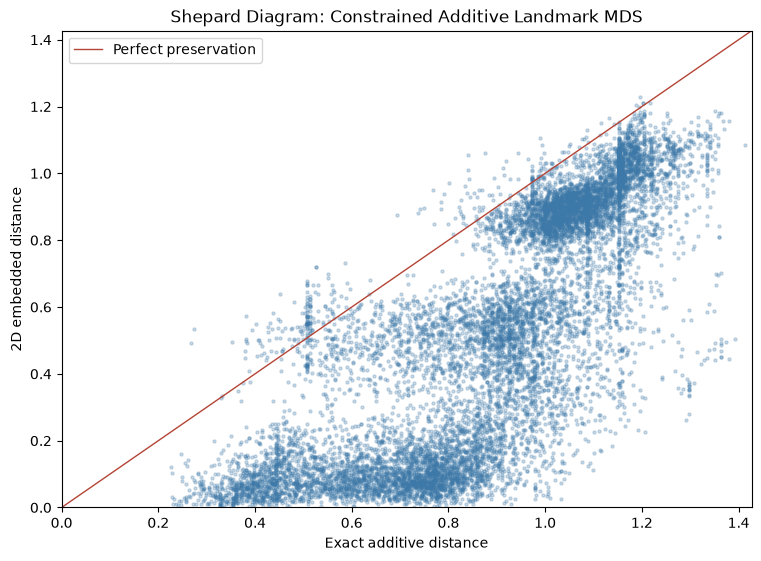

In [12]:
"""Diagnostic suite for the constrained additive landmark classical-MDS embedding."""

from scipy.stats import spearmanr
from sklearn.manifold import trustworthiness


DIAGNOSTIC_NEIGHBORHOODS = (5, 10, 20)
LEVINA_BICKEL_NEIGHBORHOODS = (10, 20)


def upper_triangle_values(matrix: np.ndarray) -> np.ndarray:
    """Return the unique off-diagonal values of a square distance matrix."""
    return matrix[np.triu_indices_from(matrix, k=1)]


def kruskal_stress_1(original: np.ndarray, embedded: np.ndarray) -> float:
    """Calculate Kruskal stress-1 with raw-distance disparities."""
    return float(np.sqrt(np.square(original - embedded).sum() / np.square(original).sum()))


def distance_ranks(distance_matrix: np.ndarray) -> np.ndarray:
    """Return one-based ranks of all other observations for each row."""
    count = len(distance_matrix)
    ranking = np.empty((count, count), dtype=np.int32)
    for index in range(count):
        order = np.argsort(distance_matrix[index], kind="stable")
        order = order[order != index]
        ranking[index, order] = np.arange(1, count)
        ranking[index, index] = 0
    return ranking


def continuity_score(high_distances: np.ndarray, low_coordinates: np.ndarray, neighborhood_size: int) -> float:
    """Compute Venna-Kaski continuity, the missing-neighbor counterpart to trustworthiness."""
    count = len(high_distances)
    low_distances = pairwise_distances(low_coordinates)
    high_ranks = distance_ranks(high_distances)
    low_ranks = distance_ranks(low_distances)
    penalty = 0
    for index in range(count):
        high_neighbors = set(np.flatnonzero(high_ranks[index] <= neighborhood_size))
        low_neighbors = set(np.flatnonzero(low_ranks[index] <= neighborhood_size))
        missing_neighbors = high_neighbors - low_neighbors
        penalty += sum(low_ranks[index, neighbor] - neighborhood_size for neighbor in missing_neighbors)
    normalizer = count * neighborhood_size * (2 * count - 3 * neighborhood_size - 1)
    return float(1.0 - 2.0 * penalty / normalizer)


def positive_neighbor_distances(distance_matrix: np.ndarray, neighbor_count: int) -> tuple[np.ndarray, int]:
    """Find nearest strictly positive distances, excluding collision-equivalent landmarks."""
    positive_distances = []
    excluded = 0
    for index in range(len(distance_matrix)):
        neighbors = np.sort(distance_matrix[index][np.arange(len(distance_matrix)) != index])
        neighbors = neighbors[neighbors > 1e-12]
        if len(neighbors) < neighbor_count:
            excluded += 1
            continue
        positive_distances.append(neighbors[:neighbor_count])
    return np.asarray(positive_distances), excluded


def two_nn_dimension(distance_matrix: np.ndarray) -> tuple[float, int]:
    """Estimate intrinsic dimension from the two nearest strictly positive distances."""
    neighbors, excluded = positive_neighbor_distances(distance_matrix, 2)
    dimension = 1.0 / np.mean(np.log(neighbors[:, 1] / neighbors[:, 0]))
    return float(dimension), excluded


def levina_bickel_dimension(distance_matrix: np.ndarray, neighbor_count: int) -> tuple[float, int]:
    """Estimate intrinsic dimension with the Levina-Bickel local k-NN MLE."""
    neighbors, excluded = positive_neighbor_distances(distance_matrix, neighbor_count)
    local_log_ratios = np.log(neighbors[:, -1, None] / neighbors[:, :-1])
    dimension = 1.0 / np.mean(local_log_ratios.mean(axis=1))
    return float(dimension), excluded


landmark_high_distances = selected_landmark_distances
landmark_coordinates_2d = landmark_coordinates[:, :2]
landmark_coordinates_3d = landmark_coordinates[:, :3]
landmark_low_distances_2d = pairwise_distances(landmark_coordinates_2d)
landmark_low_distances_3d = pairwise_distances(landmark_coordinates_3d)

embedding_diagnostics = {}
for dimension, low_coordinates, low_distances in (
    (2, landmark_coordinates_2d, landmark_low_distances_2d),
    (3, landmark_coordinates_3d, landmark_low_distances_3d),
):
    original_pairs = upper_triangle_values(landmark_high_distances)
    embedded_pairs = upper_triangle_values(low_distances)
    shepard_rho = spearmanr(original_pairs, embedded_pairs).statistic
    neighborhood_scores = {
        neighborhood_size: {
            "trustworthiness": float(
                trustworthiness(
                    landmark_high_distances,
                    low_coordinates,
                    n_neighbors=neighborhood_size,
                    metric="precomputed",
                )
            ),
            "continuity": continuity_score(
                landmark_high_distances, low_coordinates, neighborhood_size
            ),
        }
        for neighborhood_size in DIAGNOSTIC_NEIGHBORHOODS
    }
    embedding_diagnostics[dimension] = {
        "kruskal_stress_1": kruskal_stress_1(landmark_high_distances, low_distances),
        "shepard_spearman_rho": float(shepard_rho),
        "neighborhood_scores": neighborhood_scores,
    }

two_nn_id, two_nn_excluded = two_nn_dimension(landmark_high_distances)
levina_bickel_ids = {}
for neighborhood_size in LEVINA_BICKEL_NEIGHBORHOODS:
    dimension, excluded = levina_bickel_dimension(landmark_high_distances, neighborhood_size)
    levina_bickel_ids[neighborhood_size] = {"dimension": dimension, "excluded": excluded}

intrinsic_dimensionality = {
    "two_nn": {"dimension": two_nn_id, "excluded_collision_equivalents": two_nn_excluded},
    "levina_bickel": levina_bickel_ids,
}

print(f"Diagnostics use the {len(landmark_high_distances):,} landmarks with exact additive distances.")
for dimension in (2, 3):
    diagnostic = embedding_diagnostics[dimension]
    print(
        f"\n{dimension}D: Kruskal stress-1={diagnostic['kruskal_stress_1']:.4f}; "
        f"Shepard Spearman rho={diagnostic['shepard_spearman_rho']:.4f}"
    )
    for neighborhood_size, scores in diagnostic["neighborhood_scores"].items():
        print(
            f"  k={neighborhood_size:>2}: trustworthiness={scores['trustworthiness']:.4f}; "
            f"continuity={scores['continuity']:.4f}"
        )
print(
    f"\nIntrinsic dimensionality: two-NN={two_nn_id:.2f} "
    f"({two_nn_excluded} collision-equivalent landmarks excluded)."
)
for neighborhood_size, result in levina_bickel_ids.items():
    print(
        f"  Levina-Bickel k={neighborhood_size}: {result['dimension']:.2f} "
        f"({result['excluded']} excluded)."
    )

sample_generator = np.random.default_rng(42)
sample_size = min(12_000, len(original_pairs))
sample_indices = sample_generator.choice(len(original_pairs), size=sample_size, replace=False)
fig, axis = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)
axis.scatter(
    original_pairs[sample_indices],
    upper_triangle_values(landmark_low_distances_2d)[sample_indices],
    s=5,
    alpha=0.25,
    color="#3c78a8",
    rasterized=True,
)
limits = (0.0, max(original_pairs.max(), upper_triangle_values(landmark_low_distances_2d).max()))
axis.plot(limits, limits, color="#b44436", linewidth=1, label="Perfect preservation")
axis.set(xlim=limits, ylim=limits, xlabel="Exact additive distance", ylabel="2D embedded distance")
axis.set_title("Shepard Diagram: Constrained Additive Landmark MDS")
axis.legend()
plt.show()

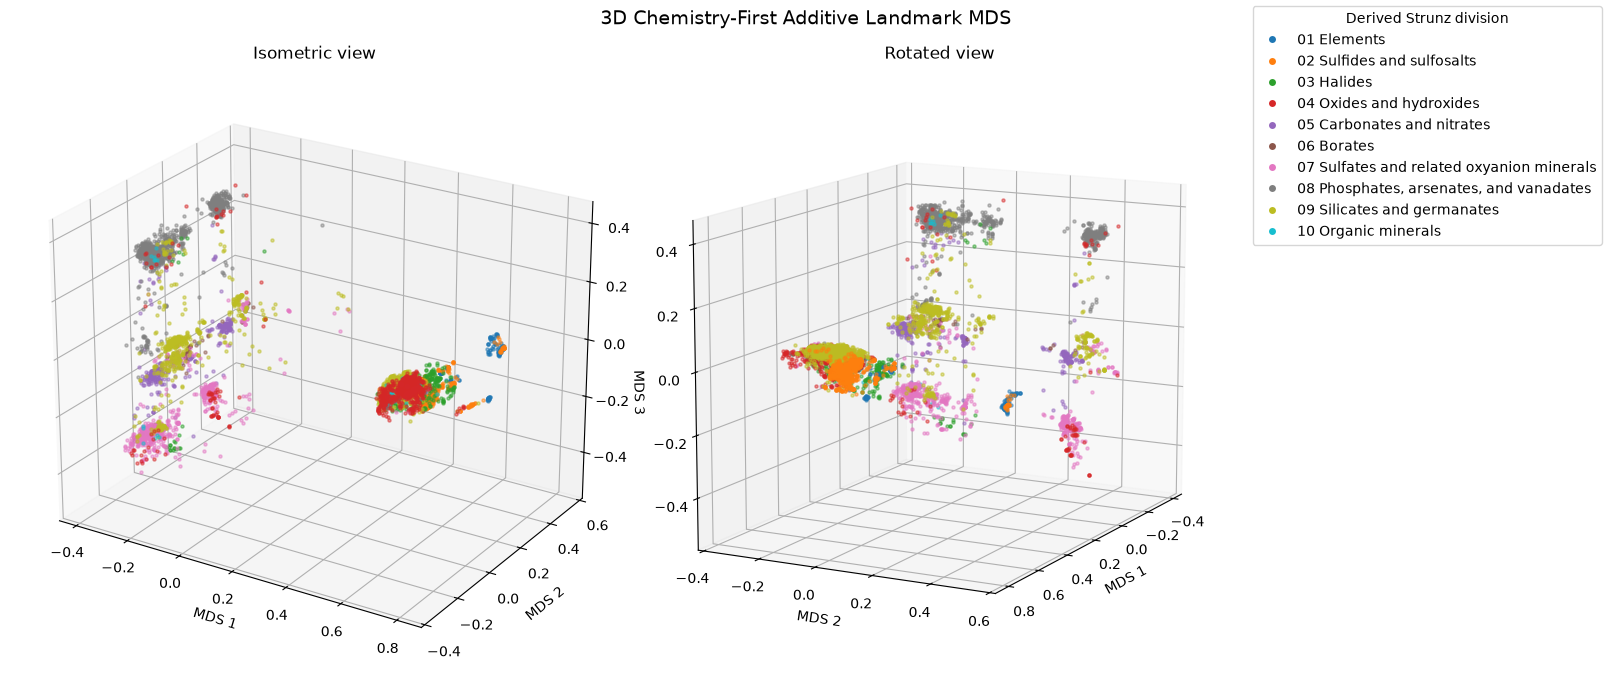

In [14]:
"""Inspect the chemistry-first additive MDS embedding in three dimensions."""

from matplotlib.lines import Line2D


MDS_3D_VIEWS = (
    (24, -58, "Isometric view"),
    (12, 28, "Rotated view"),
)
MDS_3D_COLORS = plt.get_cmap("tab10")

fig = plt.figure(figsize=(16, 7), layout="constrained")
legend_handles = []
for view_index, (elevation, azimuth, title) in enumerate(MDS_3D_VIEWS, start=1):
    axis = fig.add_subplot(1, len(MDS_3D_VIEWS), view_index, projection="3d")
    for division_index, division in enumerate(sorted(STRUNZ_TOP_LEVEL_NAMES)):
        mask = strunz_labels_array == division
        color = MDS_3D_COLORS(division_index)
        axis.scatter(
            additive_landmark_coordinates[mask, 0],
            additive_landmark_coordinates[mask, 1],
            additive_landmark_coordinates[mask, 2],
            s=5,
            alpha=0.48,
            color=color,
            depthshade=False,
            rasterized=True,
        )
        if view_index == 1:
            legend_handles.append(
                Line2D(
                    [0], [0],
                    marker="o",
                    linestyle="",
                    markersize=5,
                    markerfacecolor=color,
                    markeredgecolor="none",
                    label=f"{division} {STRUNZ_TOP_LEVEL_NAMES[division]}",
                )
            )
    axis.view_init(elev=elevation, azim=azimuth)
    axis.set(title=title, xlabel="MDS 1", ylabel="MDS 2", zlabel="MDS 3")
    axis.set_box_aspect(np.ptp(additive_landmark_coordinates, axis=0))

fig.suptitle("3D Chemistry-First Additive Landmark MDS", fontsize=14)
fig.legend(handles=legend_handles, title="Derived Strunz division", loc="outside right upper")
plt.show()

Axis signs are arbitrary in classical MDS: only opposition, correlation strength, and endpoint chemistry are interpretable. Features present in at least 25 minerals were tested.

MDS 1 most negative associations:
  -0.844  Anion-group diversity (2,796 minerals)
  -0.413  Oxyanion group: P-O4 (674 minerals)
  -0.355  Oxyanion group: S-O4 (628 minerals)
  -0.319  Dotted hydration amount (1,766 minerals)
  -0.305  Oxyanion group: As-O4 (414 minerals)
MDS 1 most positive associations:
  +0.434  Residual anion: S (737 minerals)
  +0.377  Residual-anion diversity (5,358 minerals)
  +0.281  Cation: Ag (238 minerals)
  +0.279  Cation: Sb (344 minerals)
  +0.240  Residual anion: As (393 minerals)

MDS 2 most negative associations:
  -0.761  Residual anion: O (4,033 minerals)
  -0.725  Cation: H (2,539 minerals)
  -0.418  Cation-element diversity (6,140 minerals)
  -0.320  Residual-anion diversity (5,358 minerals)
  -0.312  Dotted hydration amount (1,766 minerals)
MDS 2 most positive association

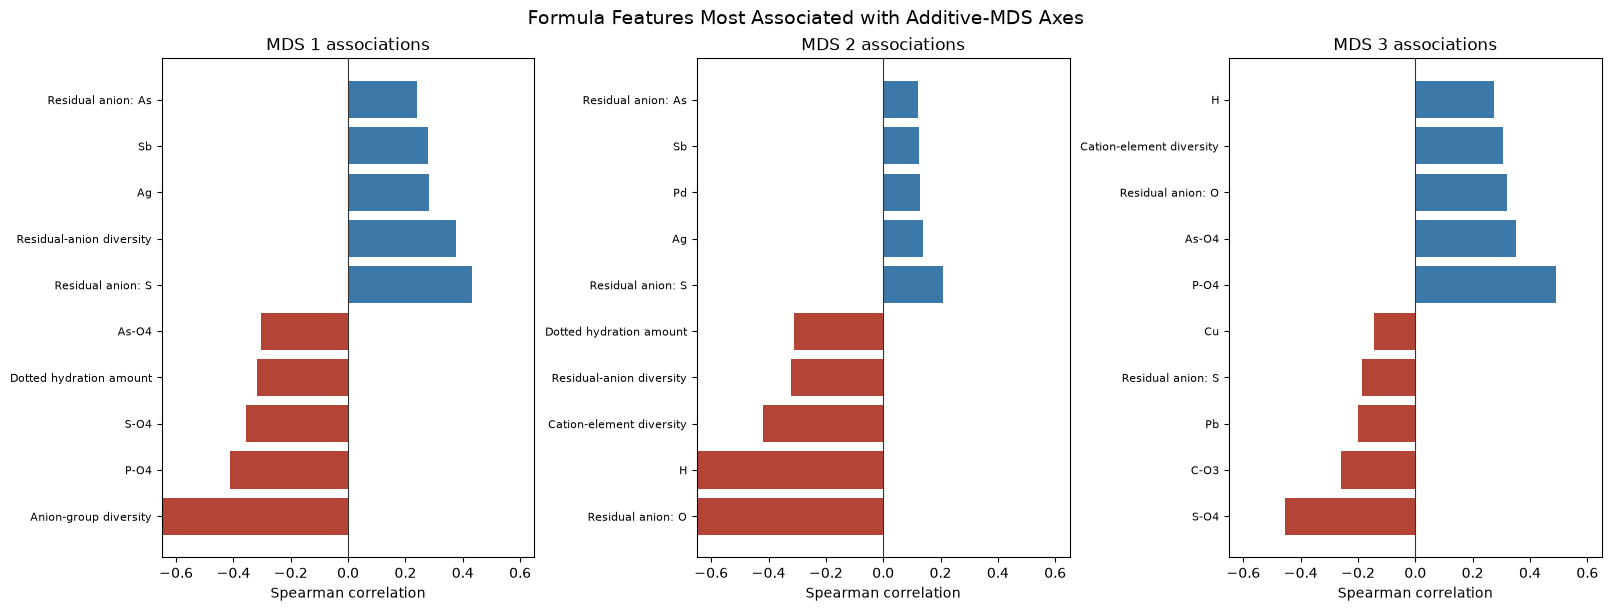

In [15]:
"""Interpret the three chemistry-first additive-MDS axes with formula-derived features."""

from scipy.stats import spearmanr


AXIS_FEATURE_MINERAL_COUNT = 25
AXIS_EXTREME_COUNT = 8


def profile_element_set(profile: dict[str, object], component: str) -> set[str]:
    """Return element symbols present in one sparse additive-profile component."""
    labels, _ = profile[component]
    return {parse_feature_label(label)[0] for label in labels}


def mineral_axis_features(profile: dict[str, object]) -> dict[str, float]:
    """Return human-readable formula features for interpreting, not defining, MDS axes."""
    features: dict[str, float] = {
        "Dotted hydration amount": float(profile["hydration"]),
        "Structural water amount": float(profile["structural_water"]),
        "Anion-group diversity": float(len(profile["anion_group"][0])),
        "Cation-element diversity": float(len(profile_element_set(profile, "cations"))),
        "Residual-anion diversity": float(len(profile_element_set(profile, "extra_anions"))),
    }
    for group in profile["anion_group"][0]:
        features[f"Oxyanion group: {group}"] = 1.0
    for element in profile_element_set(profile, "cations"):
        features[f"Cation: {element}"] = 1.0
    for element in profile_element_set(profile, "extra_anions"):
        features[f"Residual anion: {element}"] = 1.0
    return features


axis_feature_rows = [mineral_axis_features(profile) for profile in additive_profiles]
axis_feature_names = sorted({name for row in axis_feature_rows for name in row})
axis_feature_matrix = np.array(
    [[row.get(name, 0.0) for row in axis_feature_rows] for name in axis_feature_names],
    dtype=float,
)
axis_feature_counts = np.count_nonzero(axis_feature_matrix, axis=1)
axis_feature_mask = (axis_feature_counts >= AXIS_FEATURE_MINERAL_COUNT) & (
    axis_feature_counts < len(additive_profiles) - AXIS_FEATURE_MINERAL_COUNT
)
axis_feature_names = np.asarray(axis_feature_names)[axis_feature_mask]
axis_feature_matrix = axis_feature_matrix[axis_feature_mask]
axis_feature_counts = axis_feature_counts[axis_feature_mask]

axis_interpretation = {}
for axis_index in range(3):
    coordinates = additive_landmark_coordinates[:, axis_index]
    correlations = np.array(
        [spearmanr(coordinates, values).statistic for values in axis_feature_matrix],
        dtype=float,
    )
    order = np.argsort(correlations)
    axis_interpretation[axis_index + 1] = {
        "negative_features": [
            {
                "feature": str(axis_feature_names[index]),
                "rho": float(correlations[index]),
                "minerals": int(axis_feature_counts[index]),
            }
            for index in order[:8]
        ],
        "positive_features": [
            {
                "feature": str(axis_feature_names[index]),
                "rho": float(correlations[index]),
                "minerals": int(axis_feature_counts[index]),
            }
            for index in order[-8:][::-1]
        ],
    }

print(
    "Axis signs are arbitrary in classical MDS: only opposition, correlation strength, and endpoint chemistry are interpretable. "
    f"Features present in at least {AXIS_FEATURE_MINERAL_COUNT} minerals were tested."
)
for axis_index, interpretation in axis_interpretation.items():
    print(f"\nMDS {axis_index} most negative associations:")
    for entry in interpretation["negative_features"][:5]:
        print(f"  {entry['rho']:+.3f}  {entry['feature']} ({entry['minerals']:,} minerals)")
    print(f"MDS {axis_index} most positive associations:")
    for entry in interpretation["positive_features"][:5]:
        print(f"  {entry['rho']:+.3f}  {entry['feature']} ({entry['minerals']:,} minerals)")

for axis_index in range(3):
    order = np.argsort(additive_landmark_coordinates[:, axis_index])
    print(f"\nMDS {axis_index + 1} endpoints:")
    for direction, indices in (("negative", order[:AXIS_EXTREME_COUNT]), ("positive", order[-AXIS_EXTREME_COUNT:][::-1])):
        print(f"  {direction}:")
        for mineral_index in indices:
            row = rows_with_derived_strunz[mineral_index]
            profile = additive_profiles[mineral_index]
            groups = ", ".join(profile["anion_group"][0]) or "none"
            cations = ", ".join(sorted(profile_element_set(profile, "cations"))) or "none"
            print(
                f"    {row['Mineral Name']}: {row['Valence Chemistry (concise)']} "
                f"[{row[DERIVED_COLUMN]}; groups={groups}; cations={cations}]"
            )

fig, axes = plt.subplots(1, 3, figsize=(16, 6), layout="constrained")
for axis_index, axis in enumerate(axes, start=1):
    interpretation = axis_interpretation[axis_index]
    entries = [*interpretation["negative_features"][:5], *interpretation["positive_features"][:5]]
    labels = [entry["feature"].replace("Oxyanion group: ", "").replace("Cation: ", "") for entry in entries]
    values = [entry["rho"] for entry in entries]
    colors = ["#b44436" if value < 0 else "#3c78a8" for value in values]
    axis.barh(labels, values, color=colors)
    axis.axvline(0, color="#333333", linewidth=0.8)
    axis.set(xlim=(-0.65, 0.65), xlabel="Spearman correlation", title=f"MDS {axis_index} associations")
    axis.tick_params(axis="y", labelsize=8)
fig.suptitle("Formula Features Most Associated with Additive-MDS Axes", fontsize=14)
plt.show()

## Visualization Export Notes

The visualization uses 512 landmarks selected under the production additive dissimilarity. Landmark classical MDS provides coordinates; Gower interpolation places all minerals in the same three-dimensional coordinate system.

The edge file is an **exact directed 10-nearest-neighbour graph** under that additive dissimilarity. A resumable, fingerprinted full pairwise-distance cache computes each unordered mineral pair once; it is intentionally more expensive than candidate screening, because edge correctness matters more than build time for this dataset.

Map coordinates are an approximate projection. Every edge includes its exact additive distance and raw/weighted component values, which remain authoritative for relationship inspection. Relationship labels use raw component thresholds and distinguish dotted hydration from structural formula water.

In [17]:
"""Export 3D coordinates and an exact additive 10-nearest-neighbour graph."""

import os
from joblib import Parallel, delayed
from numpy.lib.format import open_memmap


VISUALIZATION_NEIGHBORS = 10
EXACT_GRAPH_SCHEMA_VERSION = "exact-additive-knn-v3"
EXACT_DISTANCE_PATH = Path("additive_exact_distances_v3.npy")
EXACT_PROGRESS_PATH = Path("additive_exact_distances_v3_progress.npy")
EXACT_MANIFEST_PATH = Path("additive_exact_distances_v3.json")
VISUALIZATION_NODES_PATH = Path("mineral_visualization_nodes.csv")
VISUALIZATION_EDGES_PATH = Path("mineral_visualization_edges.csv")
RELATIONSHIP_TAXONOMY_PATH = Path("relationship_taxonomy.json")
EXACT_BATCH_SIZE = min(8, os.cpu_count() or 1)
EXACT_WORKERS = min(8, os.cpu_count() or 1)


def exact_graph_manifest() -> dict[str, object]:
    """Return the fingerprint for the total-distance cache used by the exact graph."""
    return {
        "schema_version": EXACT_GRAPH_SCHEMA_VERSION,
        "additive_cache_manifest": manifest,
        "component_weights": selected_component_weights,
        "neighbors_per_mineral": VISUALIZATION_NEIGHBORS,
    }


def exact_distance_upper_row(source_index: int) -> tuple[int, np.ndarray]:
    """Compute exact total distances from one mineral to all later mineral indices."""
    source_profile = additive_profiles[source_index]
    distances = np.empty(len(additive_profiles) - source_index - 1, dtype=np.float32)
    for offset, target_index in enumerate(range(source_index + 1, len(additive_profiles))):
        distances[offset] = additive_mineral_distance(source_profile, additive_profiles[target_index])["total"]
    return source_index, distances


def initialize_exact_distance_cache() -> tuple[np.memmap, np.ndarray]:
    """Open a matching resumable cache or recreate it when its fingerprint changed."""
    expected_manifest = exact_graph_manifest()
    expected_shape = (len(additive_profiles), len(additive_profiles))
    cache_valid = False
    if all(path.exists() for path in (EXACT_DISTANCE_PATH, EXACT_PROGRESS_PATH, EXACT_MANIFEST_PATH)):
        try:
            cached_manifest = json.loads(EXACT_MANIFEST_PATH.read_text(encoding="utf-8"))
            cached_distances = np.load(EXACT_DISTANCE_PATH, mmap_mode="r+")
            cached_progress = np.load(EXACT_PROGRESS_PATH)
            cache_valid = (
                cached_manifest == expected_manifest
                and cached_distances.shape == expected_shape
                and cached_progress.shape == (len(additive_profiles),)
            )
        except (OSError, ValueError, json.JSONDecodeError):
            cache_valid = False
    if cache_valid:
        return cached_distances, cached_progress

    distances = open_memmap(EXACT_DISTANCE_PATH, mode="w+", dtype=np.float32, shape=expected_shape)
    distances[:] = np.nan
    np.fill_diagonal(distances, 0.0)
    distances.flush()
    progress = np.zeros(len(additive_profiles), dtype=bool)
    progress[-1] = True
    np.save(EXACT_PROGRESS_PATH, progress)
    EXACT_MANIFEST_PATH.write_text(json.dumps(expected_manifest, indent=2) + "\n", encoding="utf-8")
    return distances, progress


exact_distances, exact_progress = initialize_exact_distance_cache()
pending_rows = np.flatnonzero(~exact_progress)
for batch_start in range(0, len(pending_rows), EXACT_BATCH_SIZE):
    batch = pending_rows[batch_start : batch_start + EXACT_BATCH_SIZE]
    batch_results = Parallel(n_jobs=EXACT_WORKERS, prefer="threads")(
        delayed(exact_distance_upper_row)(int(source_index)) for source_index in batch
    )
    for source_index, distances in batch_results:
        exact_distances[source_index, source_index + 1 :] = distances
        exact_distances[source_index + 1 :, source_index] = distances
        exact_progress[source_index] = True
    exact_distances.flush()
    np.save(EXACT_PROGRESS_PATH, exact_progress)
    print(f"Completed {batch_start + len(batch):,} of {len(pending_rows):,} pending exact distance rows.")

if not exact_progress.all() or np.isnan(exact_distances).any():
    raise RuntimeError("Exact additive distance cache is incomplete; rerun this cell to resume it.")


def neighbor_edges_for_mineral(source_index: int) -> list[dict[str, object]]:
    """Return exact additive nearest-neighbour edges with component explanations."""
    candidate_indices = np.argpartition(exact_distances[source_index], VISUALIZATION_NEIGHBORS + 1)[: VISUALIZATION_NEIGHBORS + 1]
    candidate_indices = candidate_indices[candidate_indices != source_index]
    candidate_indices = candidate_indices[np.argsort(exact_distances[source_index, candidate_indices])]
    row_a = rows_with_derived_strunz[source_index]
    profile_a = additive_profiles[source_index]
    edges = []
    for rank, target_index in enumerate(candidate_indices[:VISUALIZATION_NEIGHBORS], start=1):
        row_b = rows_with_derived_strunz[int(target_index)]
        profile_b = additive_profiles[int(target_index)]
        distance = additive_mineral_distance(profile_a, profile_b)
        category, description = relationship_label(row_a, profile_a, row_b, profile_b, distance)
        edges.append(
            {
                "source_index": source_index,
                "target_index": int(target_index),
                "neighbor_rank": rank,
                "distance": float(exact_distances[source_index, target_index]),
                "relationship_category": category,
                "relationship_description": description,
                **{f"raw_{component}": distance[f"raw_{component}"] for component in COMPONENT_NAMES},
                **{f"weighted_{component}": distance[component] for component in COMPONENT_NAMES},
            }
        )
    return edges


neighbor_edges = [
    edge
    for source_index in range(len(rows_with_derived_strunz))
    for edge in neighbor_edges_for_mineral(source_index)
]

node_fieldnames = [
    "mineral_index",
    "Mineral Name",
    "Derived Strunz Top-Level",
    "Structural Groupname",
    "Crystal Systems",
    "MDS 1",
    "MDS 2",
    "MDS 3",
]
with VISUALIZATION_NODES_PATH.open("w", newline="", encoding="utf-8-sig") as output_file:
    writer = csv.DictWriter(output_file, fieldnames=node_fieldnames)
    writer.writeheader()
    for mineral_index, row in enumerate(rows_with_derived_strunz):
        writer.writerow(
            {
                "mineral_index": mineral_index,
                "Mineral Name": row["Mineral Name"],
                "Derived Strunz Top-Level": row[DERIVED_COLUMN],
                "Structural Groupname": row["Structural Groupname"],
                "Crystal Systems": row["Crystal Systems"],
                "MDS 1": additive_landmark_coordinates[mineral_index, 0],
                "MDS 2": additive_landmark_coordinates[mineral_index, 1],
                "MDS 3": additive_landmark_coordinates[mineral_index, 2],
            }
        )

edge_fieldnames = [
    "source_index",
    "target_index",
    "neighbor_rank",
    "distance",
    "relationship_category",
    "relationship_description",
    *[f"raw_{component}" for component in COMPONENT_NAMES],
    *[f"weighted_{component}" for component in COMPONENT_NAMES],
]
with VISUALIZATION_EDGES_PATH.open("w", newline="", encoding="utf-8-sig") as output_file:
    writer = csv.DictWriter(output_file, fieldnames=edge_fieldnames)
    writer.writeheader()
    writer.writerows(neighbor_edges)

RELATIONSHIP_TAXONOMY_PATH.write_text(
    json.dumps(
        {
            "component_weights": selected_component_weights,
            "distance_model": {
                "algorithm": "exact all-pairs additive dissimilarity",
                "cache_schema_version": EXACT_GRAPH_SCHEMA_VERSION,
                "formula_water_policy": manifest["formula_water_policy"],
                "map_coordinates": "landmark classical MDS with Gower interpolation; map distances are approximate",
            },
            "neighbor_graph": {
                "neighbors_per_mineral": VISUALIZATION_NEIGHBORS,
                "exact": True,
                "candidate_screening": None,
            },
            "categories": RELATIONSHIP_TAXONOMY,
        },
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

relationship_counts = Counter(edge["relationship_category"] for edge in neighbor_edges)
print(
    f"Prepared {len(rows_with_derived_strunz):,} nodes and {len(neighbor_edges):,} exact directed "
    f"{VISUALIZATION_NEIGHBORS}-NN edges."
)
print("Relationship categories among directed graph edges:", dict(relationship_counts.most_common()))
print(f"Wrote {VISUALIZATION_NODES_PATH}, {VISUALIZATION_EDGES_PATH}, and {RELATIONSHIP_TAXONOMY_PATH}.")

Completed 8 of 6,123 pending exact distance rows.
Completed 16 of 6,123 pending exact distance rows.
Completed 24 of 6,123 pending exact distance rows.
Completed 32 of 6,123 pending exact distance rows.
Completed 40 of 6,123 pending exact distance rows.
Completed 48 of 6,123 pending exact distance rows.
Completed 56 of 6,123 pending exact distance rows.
Completed 64 of 6,123 pending exact distance rows.
Completed 72 of 6,123 pending exact distance rows.
Completed 80 of 6,123 pending exact distance rows.
Completed 88 of 6,123 pending exact distance rows.
Completed 96 of 6,123 pending exact distance rows.
Completed 104 of 6,123 pending exact distance rows.
Completed 112 of 6,123 pending exact distance rows.
Completed 120 of 6,123 pending exact distance rows.
Completed 128 of 6,123 pending exact distance rows.
Completed 136 of 6,123 pending exact distance rows.
Completed 144 of 6,123 pending exact distance rows.
Completed 152 of 6,123 pending exact distance rows.
Completed 160 of 6,123 pe

## Static Web-App Export

This export is designed for a static client application: it requires no API or database. It writes three browser-friendly JSON files to `web_export/` after the exact k-NN graph cell completes:

- `mineral-map-nodes.json`: one record per mineral, including coordinates, display metadata, and an additive-composition summary.
- `mineral-map-neighbors.json`: adjacency lists indexed by source mineral ID; each entry contains its exact k-NN distance, relationship category, and component explanation.
- `mineral-map-metadata.json`: schema/version information, component weights, category definitions, and coordinate caveats.

A static site may bundle these files or load them from its own assets directory. No full pairwise distance matrix is exported.

In [ ]:
"""Export final-model nodes and exact k-NN links as static web-app data."""


WEB_EXPORT_SCHEMA_VERSION = "mineral-map-static-v1"
WEB_EXPORT_DIR = Path("web_export")
WEB_NODES_PATH = WEB_EXPORT_DIR / "mineral-map-nodes.json"
WEB_NEIGHBORS_PATH = WEB_EXPORT_DIR / "mineral-map-neighbors.json"
WEB_METADATA_PATH = WEB_EXPORT_DIR / "mineral-map-metadata.json"


def sparse_component_records(profile: dict[str, object], component: str) -> list[dict[str, float | str]]:
    """Format one normalized sparse composition component for browser display."""
    labels, masses = profile[component]
    return [
        {"label": str(label), "fraction": float(mass)}
        for label, mass in zip(labels, masses)
    ]


def web_node_record(mineral_index: int) -> dict[str, object]:
    """Build a browser-ready mineral record without exposing internal cache details."""
    row = rows_with_derived_strunz[mineral_index]
    profile = additive_profiles[mineral_index]
    division = row[DERIVED_COLUMN]
    return {
        "id": mineral_index,
        "name": row["Mineral Name"],
        "formula": row["Valence Chemistry (concise)"],
        "formulaHtml": row["Valence Chemistry (HTML)"],
        "symbol": row["IMA Mineral Symbol"],
        "yearFirstPublished": row["Year First Published"],
        "imaStatus": row["IMA Status"],
        "strunz": {
            "code": division,
            "name": STRUNZ_TOP_LEVEL_NAMES[division],
        },
        "structure": {
            "group": row["Structural Groupname"],
            "crystalSystem": row["Crystal Systems"],
            "spaceGroups": row["Space Groups"],
        },
        "coordinates": [float(value) for value in additive_landmark_coordinates[mineral_index]],
        "composition": {
            "anionGroups": sparse_component_records(profile, "anion_group"),
            "cations": sparse_component_records(profile, "cations"),
            "extraAnions": sparse_component_records(profile, "extra_anions"),
            "hydration": float(profile["hydration"]),
            "structuralWater": float(profile["structural_water"]),
        },
    }


def web_neighbor_record(edge: dict[str, object]) -> dict[str, object]:
    """Format a selected-node k-NN link and its exact component explanation."""
    return {
        "targetId": int(edge["target_index"]),
        "rank": int(edge["neighbor_rank"]),
        "distance": float(edge["distance"]),
        "category": edge["relationship_category"],
        "components": {
            component: {
                "raw": float(edge[f"raw_{component}"]),
                "weighted": float(edge[f"weighted_{component}"]),
            }
            for component in COMPONENT_NAMES
        },
    }


expected_edge_count = len(rows_with_derived_strunz) * VISUALIZATION_NEIGHBORS
if len(neighbor_edges) != expected_edge_count:
    raise ValueError(
        f"Expected {expected_edge_count:,} exact k-NN edges, received {len(neighbor_edges):,}. "
        "Run the exact graph export cell before this static export."
    )

neighbors_by_source: list[list[dict[str, object]]] = [[] for _ in rows_with_derived_strunz]
for edge in neighbor_edges:
    neighbors_by_source[int(edge["source_index"])].append(web_neighbor_record(edge))
for mineral_index, neighbors in enumerate(neighbors_by_source):
    neighbors.sort(key=lambda neighbor: neighbor["rank"])
    ranks = [neighbor["rank"] for neighbor in neighbors]
    if ranks != list(range(1, VISUALIZATION_NEIGHBORS + 1)):
        raise ValueError(f"Invalid neighbour ranks for mineral index {mineral_index}.")

WEB_EXPORT_DIR.mkdir(exist_ok=True)
node_payload = {
    "schemaVersion": WEB_EXPORT_SCHEMA_VERSION,
    "coordinateSystem": "chemistry-first additive landmark classical MDS with Gower interpolation",
    "nodes": [web_node_record(mineral_index) for mineral_index in range(len(rows_with_derived_strunz))],
}
neighbor_payload = {
    "schemaVersion": WEB_EXPORT_SCHEMA_VERSION,
    "neighborCount": VISUALIZATION_NEIGHBORS,
    "neighborsBySourceId": neighbors_by_source,
}
metadata_payload = {
    "schemaVersion": WEB_EXPORT_SCHEMA_VERSION,
    "nodeCount": len(rows_with_derived_strunz),
    "componentWeights": selected_component_weights,
    "distanceModel": {
        "algorithm": "exact additive k-nearest-neighbour graph",
        "formulaWaterPolicy": manifest["formula_water_policy"],
        "coordinateCaveat": "Map coordinates are an approximate MDS projection; edge distances and component values are authoritative.",
    },
    "relationshipCategories": RELATIONSHIP_TAXONOMY,
    "files": {
        "nodes": WEB_NODES_PATH.name,
        "neighbors": WEB_NEIGHBORS_PATH.name,
    },
}

for path, payload in (
    (WEB_NODES_PATH, node_payload),
    (WEB_NEIGHBORS_PATH, neighbor_payload),
    (WEB_METADATA_PATH, metadata_payload),
):
    path.write_text(
        json.dumps(payload, ensure_ascii=True, separators=(",", ":")) + "\n",
        encoding="utf-8",
    )

print(f"Exported {len(node_payload['nodes']):,} browser-ready nodes to {WEB_NODES_PATH}.")
print(f"Exported {len(neighbor_edges):,} exact directed k-NN links to {WEB_NEIGHBORS_PATH}.")
print(f"Exported static-app metadata to {WEB_METADATA_PATH}.")
for path in (WEB_NODES_PATH, WEB_NEIGHBORS_PATH, WEB_METADATA_PATH):
    print(f"  {path}: {path.stat().st_size / 1024 / 1024:.2f} MiB")

Exported 6,228 browser-ready nodes to web_export\mineral-map-nodes.json.
Exported 62,280 exact directed k-NN links to web_export\mineral-map-neighbors.json.
Exported static-app metadata to web_export\mineral-map-metadata.json.
  web_export\mineral-map-nodes.json: 3.85 MiB
  web_export\mineral-map-neighbors.json: 23.60 MiB
  web_export\mineral-map-metadata.json: 0.00 MiB


In [1]:
"""Compute a 3D UMAP projection from the exact additive-distance matrix.

The existing web export is updated in place so the frontend can observe the
projection after reloading. The authoritative exact neighbour distances and
composition explanations are unchanged; only node coordinates are replaced.
"""

import json
from pathlib import Path

import numpy as np

try:
    import umap
except ImportError as error:
    raise ImportError(
        "Install the notebook dependency with `pip install umap-learn` before running this cell."
    ) from error


UMAP_RANDOM_STATE = 42
UMAP_NEIGHBORS = 30
UMAP_MIN_DIST = 0.12
UMAP_SPREAD = 1.0
UMAP_METRIC = "precomputed"
UMAP_COORDINATE_SYSTEM = (
    "3D UMAP projection of the exact additive dissimilarity matrix; "
    "edge distances remain authoritative"
)

EXACT_DISTANCE_PATH = Path("additive_exact_distances_v3.npy")
WEB_EXPORT_DIR = Path("web_export")
WEB_NODES_PATH = WEB_EXPORT_DIR / "mineral-map-nodes.json"
WEB_METADATA_PATH = WEB_EXPORT_DIR / "mineral-map-metadata.json"
FRONTEND_DATA_DIR = Path("mineral-map/public/data")
FRONTEND_NODES_PATH = FRONTEND_DATA_DIR / "mineral-map-nodes.json"
FRONTEND_METADATA_PATH = FRONTEND_DATA_DIR / "mineral-map-metadata.json"

if not EXACT_DISTANCE_PATH.exists():
    raise FileNotFoundError(
        f"Missing {EXACT_DISTANCE_PATH}. Run the exact-distance/export cells first."
    )
if not WEB_NODES_PATH.exists() or not WEB_METADATA_PATH.exists():
    raise FileNotFoundError(
        "The static web export is missing. Run the existing Static Web-App Export cell first."
    )

exact_distances = np.load(EXACT_DISTANCE_PATH, mmap_mode="r")
if exact_distances.ndim != 2 or exact_distances.shape[0] != exact_distances.shape[1]:
    raise ValueError(f"Expected a square distance matrix, received {exact_distances.shape}.")
if not np.isfinite(exact_distances).all():
    raise ValueError("The exact distance matrix contains non-finite values.")

# UMAP's precomputed-distance mode expects zero self-distances and non-negative
# dissimilarities. A copy is intentionally avoided: the cache is already a
# memory-mapped float32 matrix and UMAP can consume it directly.
if not np.allclose(np.diag(exact_distances), 0.0):
    raise ValueError("The exact distance matrix must have a zero diagonal.")
if (exact_distances < 0).any():
    raise ValueError("The exact distance matrix must not contain negative values.")

umap_model = umap.UMAP(
    n_components=3,
    metric=UMAP_METRIC,
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    spread=UMAP_SPREAD,
    random_state=UMAP_RANDOM_STATE,
    transform_seed=UMAP_RANDOM_STATE,
    verbose=True,
)
umap_coordinates = umap_model.fit_transform(exact_distances).astype(np.float32)

with WEB_NODES_PATH.open(encoding="utf-8") as input_file:
    node_payload = json.load(input_file)
with WEB_METADATA_PATH.open(encoding="utf-8") as input_file:
    metadata_payload = json.load(input_file)

nodes = node_payload.get("nodes")
if not isinstance(nodes, list) or len(nodes) != len(umap_coordinates):
    raise ValueError(
        f"Node count ({len(nodes) if isinstance(nodes, list) else 'invalid'}) does not match "
        f"the distance matrix ({len(umap_coordinates)})."
    )

for node, coordinates in zip(nodes, umap_coordinates):
    node["coordinates"] = [float(value) for value in coordinates]

node_payload["coordinateSystem"] = UMAP_COORDINATE_SYSTEM
metadata_payload["coordinateSystem"] = UMAP_COORDINATE_SYSTEM
metadata_payload["distanceModel"]["mapAlgorithm"] = "UMAP"
metadata_payload["distanceModel"]["mapParameters"] = {
    "nComponents": 3,
    "metric": UMAP_METRIC,
    "nNeighbors": UMAP_NEIGHBORS,
    "minDist": UMAP_MIN_DIST,
    "spread": UMAP_SPREAD,
    "randomState": UMAP_RANDOM_STATE,
}
metadata_payload["distanceModel"]["coordinateCaveat"] = (
    "UMAP coordinates preserve local neighbourhood structure approximately; "
    "edge distances and component values remain authoritative."
)

for path, payload in (
    (WEB_NODES_PATH, node_payload),
    (WEB_METADATA_PATH, metadata_payload),
    (FRONTEND_NODES_PATH, node_payload),
    (FRONTEND_METADATA_PATH, metadata_payload),
):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, ensure_ascii=True, separators=(",", ":")) + "\n", encoding="utf-8")

print(
    f"Exported UMAP coordinates for {len(nodes):,} minerals to {WEB_NODES_PATH} "
    f"and {FRONTEND_NODES_PATH}."
)
print(
    f"UMAP parameters: n_neighbors={UMAP_NEIGHBORS}, min_dist={UMAP_MIN_DIST}, "
    f"random_state={UMAP_RANDOM_STATE}. Reload the frontend to observe the map."
)


c:\My Things\HTML\Demonin's Item Shop\other\minerals\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\My Things\HTML\Demonin's Item Shop\other\minerals\.venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\My Things\HTML\Demonin's Item Shop\other\minerals\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(metric='precomputed', min_dist=0.12, n_components=3, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Fri Aug  7 16:51:39 2026 Construct fuzzy simplicial set
Fri Aug  7 16:51:39 2026 Finding Nearest Neighbors
Fri Aug  7 16:51:50 2026 Finished Nearest Neighbor Search
Fri Aug  7 16:51:57 2026 Construct embedding


Epochs completed:   1%| ▏          7/500 [00:01]

	completed  0  /  500 epochs


Epochs completed:  12%| █▏         58/500 [00:02]

...

	completed  400  /  500 epochs


Epochs completed:  92%| █████████▏ 458/500 [00:14]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:15]


Fri Aug  7 16:52:14 2026 Finished embedding
Exported UMAP coordinates for 6,228 minerals to web_export\mineral-map-nodes.json and mineral-map\public\data\mineral-map-nodes.json.
UMAP parameters: n_neighbors=30, min_dist=0.12, random_state=42. Reload the frontend to observe the map.


In [2]:
"""Compute and export a normalized 3D force-directed layout of the exact k-NN graph.

The graph is loaded from the exact additive graph export. Edge distances remain
authoritative; this cell only replaces coordinates.
"""

import csv
import json
from pathlib import Path

import networkx as nx
import numpy as np


FORCE_RANDOM_STATE = 42
FORCE_ITERATIONS = 200
FORCE_LAYOUT_SCALE = 1.0
FORCE_LAYOUT_K = 0.12
FORCE_COORDINATE_SYSTEM = (
    "normalized 3D force-directed layout of the exact additive k-nearest-neighbour graph; "
    "edge distances remain authoritative"
)

EDGE_PATH = Path("mineral_visualization_edges.csv")
WEB_NODES_PATH = Path("web_export/mineral-map-nodes.json")
WEB_METADATA_PATH = Path("web_export/mineral-map-metadata.json")
FRONTEND_NODES_PATH = Path("mineral-map/public/data/mineral-map-nodes.json")
FRONTEND_METADATA_PATH = Path("mineral-map/public/data/mineral-map-metadata.json")

if not EDGE_PATH.exists():
    raise FileNotFoundError(f"Missing {EDGE_PATH}. Run the exact graph export first.")
if not WEB_NODES_PATH.exists() or not WEB_METADATA_PATH.exists():
    raise FileNotFoundError("Run the existing static web-app export cell before this layout cell.")

with WEB_NODES_PATH.open(encoding="utf-8") as input_file:
    node_payload = json.load(input_file)
with WEB_METADATA_PATH.open(encoding="utf-8") as input_file:
    metadata_payload = json.load(input_file)

nodes = node_payload.get("nodes")
if not isinstance(nodes, list) or not nodes:
    raise ValueError("The web node export does not contain any nodes.")
node_count = len(nodes)

graph = nx.Graph()
graph.add_nodes_from(range(node_count))

with EDGE_PATH.open(newline="", encoding="utf-8-sig") as input_file:
    edge_rows = list(csv.DictReader(input_file))
if not edge_rows:
    raise ValueError(f"The edge export {EDGE_PATH} is empty.")

edge_distances = np.asarray([float(edge["distance"]) for edge in edge_rows], dtype=np.float64)
distance_floor = max(float(np.percentile(edge_distances, 5)), 1e-6)
distance_ceiling = max(float(np.percentile(edge_distances, 95)), distance_floor)
for edge in edge_rows:
    source = int(edge["source_index"])
    target = int(edge["target_index"])
    if not (0 <= source < node_count and 0 <= target < node_count):
        raise ValueError(f"Edge index outside node range: {source} -> {target}")
    distance = float(edge["distance"])
    normalized_distance = np.clip(
        (distance - distance_floor) / (distance_ceiling - distance_floor), 0.0, 1.0
    )
    weight = 1.0 - normalized_distance
    existing = graph.get_edge_data(source, target)
    if existing is None or weight > existing["weight"]:
        graph.add_edge(source, target, weight=float(0.2 + 0.8 * weight))

# Start from the current export to make the layout reproducible while allowing
# the graph forces to pull disconnected-looking composition regions together.
initial_coordinates = np.asarray([node["coordinates"] for node in nodes], dtype=np.float64)
if initial_coordinates.shape != (node_count, 3):
    raise ValueError(f"Expected {node_count} existing 3D coordinates, received {initial_coordinates.shape}.")
initial_coordinates -= initial_coordinates.mean(axis=0, keepdims=True)
initial_scale = np.max(np.linalg.norm(initial_coordinates, axis=1))
initial_coordinates /= max(initial_scale, 1e-9)
initial_position = {index: initial_coordinates[index] for index in range(node_count)}

positions = nx.spring_layout(
    graph,
    dim=3,
    seed=FORCE_RANDOM_STATE,
    iterations=FORCE_ITERATIONS,
    k=FORCE_LAYOUT_K,
    scale=FORCE_LAYOUT_SCALE,
    weight="weight",
    pos=initial_position,
)
force_coordinates = np.asarray([positions[index] for index in range(node_count)], dtype=np.float64)

# Normalize to a compact, centered cube so the original camera configuration
# remains appropriate and no cluster is lost to arbitrary layout scale.
force_coordinates -= force_coordinates.mean(axis=0, keepdims=True)
maximum_extent = np.max(np.abs(force_coordinates))
force_coordinates /= max(maximum_extent, 1e-9)
force_coordinates *= 0.95

for node, coordinates in zip(nodes, force_coordinates):
    node["coordinates"] = [float(value) for value in coordinates]

node_payload["coordinateSystem"] = FORCE_COORDINATE_SYSTEM
metadata_payload["coordinateSystem"] = FORCE_COORDINATE_SYSTEM
metadata_payload["distanceModel"]["mapAlgorithm"] = "weighted 3D force-directed k-NN graph"
metadata_payload["distanceModel"]["mapParameters"] = {
    "dimensions": 3,
    "iterations": FORCE_ITERATIONS,
    "k": FORCE_LAYOUT_K,
    "randomState": FORCE_RANDOM_STATE,
    "undirectedEdges": graph.number_of_edges(),
    "normalization": "centered and scaled to approximately [-0.95, 0.95] on each axis",
}
metadata_payload["distanceModel"]["coordinateCaveat"] = (
    "Force-directed coordinates are normalized layout positions; "
    "edge distances and component values remain authoritative."
)

for path, payload in (
    (WEB_NODES_PATH, node_payload),
    (WEB_METADATA_PATH, metadata_payload),
    (FRONTEND_NODES_PATH, node_payload),
    (FRONTEND_METADATA_PATH, metadata_payload),
):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, ensure_ascii=True, separators=(",", ":")) + "\n", encoding="utf-8")

print(
    f"Exported normalized force-directed coordinates for {node_count:,} minerals "
    f"using {graph.number_of_edges():,} undirected edges."
)
print(f"Wrote {WEB_NODES_PATH} and {FRONTEND_NODES_PATH}.")


Exported normalized force-directed coordinates for 6,228 minerals using 43,198 undirected edges.
Wrote web_export\mineral-map-nodes.json and mineral-map\public\data\mineral-map-nodes.json.


In [4]:
# Restore the exact graph neighbour payload after any exploratory approximate export.
from pathlib import Path
import csv
import json

exact_edge_path = Path("mineral_visualization_edges.csv")
exact_web_neighbors_path = Path("web_export/mineral-map-neighbors.json")
exact_frontend_neighbors_path = Path("mineral-map/public/data/mineral-map-neighbors.json")
exact_components = ("anion_group", "cations", "extra_anions", "hydration", "structural_water", "structure")
with exact_edge_path.open(newline="", encoding="utf-8-sig") as input_file:
    exact_edge_rows = list(csv.DictReader(input_file))
exact_node_count = max(max(int(edge["source_index"]), int(edge["target_index"])) for edge in exact_edge_rows) + 1
exact_neighbors_by_source = [[] for _ in range(exact_node_count)]
for edge in exact_edge_rows:
    source = int(edge["source_index"])
    exact_neighbors_by_source[source].append({
        "targetId": int(edge["target_index"]),
        "rank": int(edge["neighbor_rank"]),
        "distance": float(edge["distance"]),
        "category": edge.get("category", "exact_additive_knn"),
        "components": {
            component: {
                "raw": float(edge[f"raw_{component}"]),
                "weighted": float(edge.get(f"weighted_{component}", 0.0)),
            }
            for component in exact_components
        },
    })
exact_neighbor_payload = {
    "schemaVersion": "mineral-map-static-v1",
    "neighborCount": 10,
    "neighborsBySourceId": exact_neighbors_by_source,
}
for path in (exact_web_neighbors_path, exact_frontend_neighbors_path):
    path.write_text(json.dumps(exact_neighbor_payload, ensure_ascii=True, separators=(",", ":")) + "\n", encoding="utf-8")
print(f"Restored exact neighbour payload with {len(exact_edge_rows):,} directed edges.")


Restored exact neighbour payload with 62,280 directed edges.
